In [5]:
import milaDS
import ds 
import clustering_metrics as cmetrics
import clustering_methods as clustering
import clustering_external_tools as ctools

import ploting as cplt

import os
import numpy as np
import pandas as pd
import re
import random

from astropy import units as u
from astropy.stats import biweight_location
from astropy.stats import biweight_scale

from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM
from astropy import constants as const
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import confusion_matrix

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
import importlib
importlib.reload(clustering)
importlib.reload(ctools)
importlib.reload(cmetrics)
importlib.reload(cplt)

<module 'ploting' from '/mnt/c/Users/gasep/OneDrive/Documentos/GitHub/ClusteringComparison/ploting.py'>

In [8]:
def to_kpc(ra, dec, z, x_center, y_center):
    
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

    dist = cosmo.angular_diameter_distance(z)

    ra = ra - x_center
    dec = dec - y_center

    x = (ra * dist).to(u.Mpc, u.dimensionless_angles()).value

    y = (dec * dist).to(u.Mpc, u.dimensionless_angles()).value

    return x*1000,y*1000

In [9]:
def to_vel(z_gal, z_clus):

    c = const.c.value
    vel = (c*(z_gal - z_clus)/(1 + z_clus))

    return vel

In [10]:
def fix_columns(dfs):

    for i in range(len(dfs)):
        # Split the concatenated column into multiple columns
        split_cols = dfs[i]['# galaxyId haloId haloId_dor ra dec z_app log(m_200)'].str.split(' ', expand=True)

        # Concatenate split_cols with combined_df
        split_df = pd.concat([dfs[i], split_cols], axis=1)

        # Assign appropriate column names
        split_df.columns = ['original_col', 'galaxyId', 'haloId', 'haloId_dor', 'ra', 'dec', 'z_app', 'log(m_200)']

        # Drop the original concatenated column and unnecessary columns
        split_df = split_df.drop(columns=['original_col'])


        numeric_columns = ['galaxyId', 'haloId', 'haloId_dor', 'ra', 'dec', 'z_app', 'log(m_200)']
        split_df[numeric_columns] = split_df[numeric_columns].apply(pd.to_numeric, errors='coerce')
        dfs[i] = split_df
    
    return dfs

In [11]:
def load_data(path):

    files = os.listdir(path)

    # Filter .cat files
    cat_files = [file for file in files if file.endswith('.cat')]

    def extract_number(file_name):
        match = re.search(r'(\d+)', file_name)  # Find the number in the filename
        return int(match.group()) if match else 0  # Return the number as an integer

    cat_files_sorted = sorted(cat_files, key=extract_number)

    # Initialize an empty list to hold individual DataFrames
    dfs = []

    # Loop through each .cat file, read into a DataFrame, and append to the list
    for file in cat_files_sorted:
        file_path = os.path.join(path, file)
        df = pd.read_csv(file_path, delimiter='\t')
        dfs.append(df)

    dfs = fix_columns(dfs)

    
    for df in dfs:
        df['haloId_dor'] = df['haloId_dor'] - 1

    return dfs


In [12]:
def extract_df(data_frame):

    X_data = data_frame.iloc[:,3].values
    Y_data = data_frame.iloc[:,4].values
    Z_data = data_frame.iloc[:,5].values

    #min + (max - min)/2 = (2min + max - min)/2
    x_center = (min(X_data) + max(X_data))/2
    y_center = (min(Y_data) + max(Y_data))/2

    Z_clus = np.mean(Z_data);

    return X_data, Y_data, Z_data, x_center, y_center, Z_clus

Accuracy

In [11]:
mocks_path = "/Users/gasep/OneDrive/Documentos/Dresler-Schetman/Data/Mocks/clean halos"
dfs = load_data(mocks_path)
members_count_threshold = 300
df_subset = [df for df in dfs if len(df) > members_count_threshold]


In [13]:
def run_algorithms(data, algorithms, params_grid, pertubation_number, original_labels):

    results = []
    lax_original_labels = np.where(original_labels >= 0, 1, -1)

    for params in params_grid:
        alg_results = {}
        for alg in algorithms.keys():

            strict_completitudes = []
            lax_completitudes = []
            strict_purities = []
            lax_purities = []
            strict_f1_scores = []
            lax_f1_scores = []
            strict_rand_indexes = []
            lax_rand_indexes = []
            dunn_indexes = []
            calinski_harabaz_indexes = []

            result = {}

            for i in range(pertubation_number):

                labels, probabilities, clusterer = algorithms[alg](data, params)

                mapped_labels, mapping = ctools.map_values(labels, original_labels)
                print(mapping)
                #print(labels)

                lax_labels = np.where(labels >= 0, 1, -1)

                lax_tp, lax_fp, lax_tn, lax_fn = cmetrics.get_match(lax_original_labels, lax_labels)

                lax_completitudes.append(recall_score(lax_original_labels, lax_labels, average='macro'))

                lax_purities.append(cmetrics.purity_score(lax_original_labels, lax_labels))

                lax_f1_scores.append(f1_score(lax_original_labels, lax_labels, average='macro'))

                lax_rand_indexes.append(cmetrics.get_rand_index(lax_tp, lax_tp + lax_fp, lax_tp + lax_fn))


                tp, fp, tn, fn = cmetrics.get_match(original_labels, mapped_labels)

                strict_completitudes.append(recall_score(original_labels, mapped_labels, average='macro'))

                strict_purities.append(cmetrics.purity_score(original_labels, labels))

                strict_f1_scores.append(f1_score(original_labels, labels, average='macro'))

                strict_rand_indexes.append(cmetrics.get_rand_index(tp, tp + fp, tp + fn))

                dunn_indexes.append(cmetrics.get_dunn_index(data, labels))
                calinski_harabaz_indexes.append(calinski_harabasz_score(data, labels))
                
            result['lax_completitudes_location'] = biweight_location(lax_completitudes)
            result['lax_completitudes_scale'] = biweight_scale(lax_completitudes)
            result['lax_completitudes_mean'] = np.mean(lax_completitudes)
            result['lax_completitudes_std'] = np.std(lax_completitudes)


            result['lax_purity_location'] = biweight_location(lax_purities)
            result['lax_purity_scale'] = biweight_scale(lax_purities)
            result['lax_purity_mean'] = np.mean(lax_purities)
            result['lax_purity_std'] = np.std(lax_purities)

            
            result['lax_f1Score_location'] = biweight_location(lax_f1_scores)
            result['lax_f1Score_scale'] = biweight_scale(lax_f1_scores)
            result['lax_f1Score_mean'] = np.mean(lax_f1_scores)
            result['lax_f1Score_std'] = np.std(lax_f1_scores)

            
            result['lax_randIndex_location'] = biweight_location(lax_rand_indexes)
            result['lax_randIndex_scale'] = biweight_scale(lax_rand_indexes)
            result['lax_randIndex_mean'] = np.mean(lax_rand_indexes)
            result['lax_randIndex_std'] = np.std(lax_rand_indexes)

            
            result['strict_completitudes_location'] = biweight_location(strict_completitudes)
            result['strict_completitudes_scale'] = biweight_scale(strict_completitudes)
            result['strict_completitudes_mean'] = np.mean(strict_completitudes)
            result['strict_completitudes_std'] = np.std(strict_completitudes)


            result['strict_purity_location'] = biweight_location(strict_purities)
            result['strict_purity_scale'] = biweight_scale(strict_purities)
            result['strict_purity_mean'] = np.mean(strict_purities)
            result['strict_purity_std'] = np.std(strict_purities)

            
            result['strict_f1Score_location'] = biweight_location(strict_f1_scores)
            result['strict_f1Score_scale'] = biweight_scale(strict_f1_scores)
            result['strict_f1Score_mean'] = np.mean(strict_f1_scores)
            result['strict_f1Score_std'] = np.std(strict_f1_scores)

            
            result['strict_randIndex_location'] = biweight_location(strict_rand_indexes)
            result['strict_randIndex_scale'] = biweight_scale(strict_rand_indexes)
            result['strict_randIndex_mean'] = np.mean(strict_rand_indexes)
            result['strict_randIndex_std'] = np.std(strict_rand_indexes)


            result['dunnIndex_location'] = biweight_location(dunn_indexes)
            result['dunnIndex_scale'] = biweight_scale(dunn_indexes)
            result['dunnIndex_mean'] = np.mean(dunn_indexes)
            result['dunnIndex_std'] = np.std(dunn_indexes)

            
            result['calinskiHarabazIndex_location'] = biweight_location(calinski_harabaz_indexes)
            result['calinskiHarabazIndex__scale'] = biweight_scale(calinski_harabaz_indexes)
            result['calinskiHarabazIndex__mean'] = np.mean(calinski_harabaz_indexes)
            result['calinskiHarabazIndex__std'] = np.std(calinski_harabaz_indexes)

            alg_results[alg] = result

        results.append(alg_results)
    return results



In [14]:
def save_results_to_xsl(output, params_grid, filename):
    """
    Save clustering results stored in the output dictionary to an Excel file.

    Parameters:
        output: Dictionary where keys are integers (sample index) and values are results.
        params_grid: List of parameter dictionaries for each result set.
        algorithms: Dictionary of algorithms used.
        filename: Name of the Excel file to save.
    """
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        for sample_index, results in output.items():
            for i, params in enumerate(params_grid):
                # Create a new sheet for each parameter grid and sample
                sheet_name = f"Cluster_{sample_index} - Params_Set_{i+1}"
                
                # Save parameters as a table at the top of the sheet
                params_table = pd.DataFrame(list(params.items()), columns=["Parameter", "Value"])
                params_table.to_excel(writer, sheet_name=sheet_name, index=False, startrow=0)
                
                start_row = len(params_table) + 2  # Leave some space after the params table
                
                alg_results = results[i]

                for alg, result in alg_results.items():
                    # Add custom text (algorithm key) to the sheet
                    custom_text_df = pd.DataFrame(columns=[alg])
                    custom_text_df.to_excel(writer, sheet_name=sheet_name, index=False, startrow=start_row, header=True)

                    # Prepare the result table for the algorithm
                    result_table = pd.DataFrame(list(result.items()), columns=["Metric", "Value"])
                    
                    # Write algorithm results under the parameters table
                    result_table.to_excel(writer, sheet_name=sheet_name, index=False, startrow=start_row + 1, header=True)
                    
                    # Update start_row for the next algorithm
                    start_row += len(result_table) + 3

    print(f"Results saved to {filename}")

In [12]:
sample_size = 30

df_samples = random.sample(df_subset, sample_size)
df_subset = [df for df in df_subset if not any(df.equals(sample) for sample in df_samples)]

perturbations_number = 1


algorithms = {}

data_frames = {}

params_grid = []

In [13]:
params = {
    "max_clusters" : 40,
    "covariance_type" : 'full',
    "min_cluster_size" : 5,
    "random_state" : 0,
    "min_eps" : 0.5,
    "max_eps" : np.inf,
    "linkage" : 'ward',
    "clustering_threshold" : 0.5,
    'key_point' : 'location'
}

params_grid.append(params)

algorithms['GMM'] = clustering.run_GMM
algorithms['DBSCAN'] = clustering.run_DBSCAN
algorithms['HDBSCAN'] = clustering.run_HDBSCAN
algorithms['Optics'] = clustering.run_OPTICS
algorithms['Kmeans'] = clustering.run_Kmeans
algorithms['Aglomerative'] = clustering.run_Aglomerative_Clustering
algorithms['Affinity'] = clustering.run_Affinity_Propagation

In [1]:
f1_score = {}
y_values = {}

for alg in algorithms.keys():

    f1_score[alg] = []
    y_values[alg] = []

f1_score['DS+'] = []
y_values['DS+'] = []

for sample in df_samples:

    X_data, Y_data, Z_data, x_center, y_center, Z_clus = extract_df(sample)

    data = np.column_stack((X_data, Y_data))

    og_labels = np.array(sample.iloc[:, 2].values, dtype=int)     

    for alg in algorithms.keys():

        labels, probs, clusterer = algorithms[alg](data, params)
        
        distances, dit_comp, dist_pur, overlap, overlap_comp, overlap_pur, overlap_f1 = ctools.overlap_data(data, og_labels, labels)

        f1_score[alg].append(overlap_f1)

    X_Kpc, Y_Kpc = to_kpc(X_data, Y_data, Z_data, x_center, y_center)
    V_data = to_vel(Z_data, Z_clus)

    labels, prob, clusterer = clustering.run_DSP_test(X_Kpc, Y_Kpc, V_data, Z_clus)

    distances, dit_comp, dist_pur, overlap, overlap_comp, overlap_pur, overlap_f1 = ctools.overlap_data(data, og_labels, labels)
    f1_score['DS+'].append(overlap_f1)


x_values = np.linspace(0, 1, 100)

for alg in algorithms.keys():
    for x in x_values:
        percentages = []

        for df in f1_score[alg]:
            if df.empty:
                continue
            count_above_x = (df > x).any(axis=0).sum()
            percentage = (count_above_x / df.shape[1]) * 100
            percentages.append(percentage)
        
        # Compute the average percentage across all matrices
        avg_percentage = np.mean(percentages) if percentages else 0
        y_values[alg].append(avg_percentage)

for x in x_values:
    percentages = []

    for df in f1_score['DS+']:
        if df.empty:
            continue
        count_above_x = (df > x).any(axis=0).sum()
        percentage = (count_above_x / df.shape[1]) * 100
        percentages.append(percentage)
    
    # Compute the average percentage across all matrices
    avg_percentage = np.mean(percentages) if percentages else 0
    y_values['DS+'].append(avg_percentage)





NameError: name 'algorithms' is not defined

In [ ]:
f1_score = {}
y_values = {}

for alg in algorithms.keys():

    f1_score[alg] = []
    y_values[alg] = []

f1_score['DS+'] = []
y_values['DS+'] = []

for sample in df_samples:

    X_data, Y_data, Z_data, x_center, y_center, Z_clus = extract_df(sample)

    data = np.column_stack((X_data, Y_data))

    og_labels = np.array(sample.iloc[:, 2].values, dtype=int)     

    for alg in algorithms.keys():

        labels, probs, clusterer = algorithms[alg](data, params)
        
        distances, dit_comp, dist_pur, overlap, overlap_comp, overlap_pur, overlap_f1 = ctools.overlap_data(data, og_labels, labels)

        f1_score[alg].append(overlap_f1)

    X_Kpc, Y_Kpc = to_kpc(X_data, Y_data, Z_data, x_center, y_center)
    V_data = to_vel(Z_data, Z_clus)

    labels, prob, clusterer = clustering.run_DSP_test(X_Kpc, Y_Kpc, V_data, Z_clus)

    distances, dit_comp, dist_pur, overlap, overlap_comp, overlap_pur, overlap_f1 = ctools.overlap_data(data, og_labels, labels)
    f1_score['DS+'].append(overlap_f1)


x_values = np.linspace(0, 1, 100)

for alg in algorithms.keys():
    for x in x_values:
        percentages = []

        for df in f1_score[alg]:
            if df.empty:
                continue
            count_above_x = (df > x).any(axis=0).sum()
            percentage = (count_above_x / df.shape[1]) * 100
            percentages.append(percentage)
        
        # Compute the average percentage across all matrices
        avg_percentage = np.mean(percentages) if percentages else 0
        y_values[alg].append(avg_percentage)

for x in x_values:
    percentages = []

    for df in f1_score['DS+']:
        if df.empty:
            continue
        count_above_x = (df > x).any(axis=0).sum()
        percentage = (count_above_x / df.shape[1]) * 100
        percentages.append(percentage)
    
    # Compute the average percentage across all matrices
    avg_percentage = np.mean(percentages) if percentages else 0
    y_values['DS+'].append(avg_percentage)



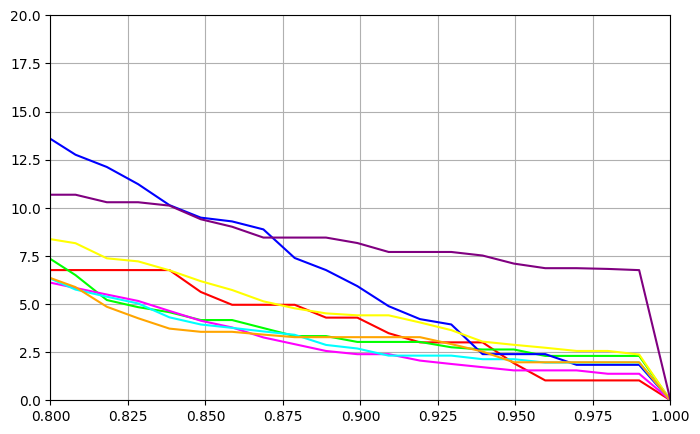

In [ ]:
colors = ["#FF0000", "#00FF00", "#0000FF", "#FFFF00", "#FF00FF", "#00FFFF", "#FFA500", "#800080"]

# Create the plot
plt.figure(figsize=(8, 5))

# Store the line objects for the legend
lines = []

# Plot each algorithm's data with a unique color
for i, alg in enumerate(f1_score.keys()):
    line = plt.plot(x_values, y_values[alg], label = alg, color=colors[i % len(colors)])
    lines.append(line)



# Graph styling
#plt.xlabel("F1-Score Threshold")
#plt.ylabel("Average Substructure-Cluster Pair Avobe Threshold")
#plt.title("Comparison of Algorithms")
plt.grid()
#plt.legend()  # Assign correct labels to colors
#plt.show()

plt.xlim(0.8, 1)
plt.ylim(0,20)

plt.show()


In [26]:
output = {}

filename = "test.xlsx"

for index, c_df in enumerate(df_samples):

    X_data, Y_data, Z_data, x_center, y_center, Z_clus = extract_df(c_df)

    data = np.column_stack((X_data, Y_data))

    original_labels = np.array(c_df.iloc[:, 2].values, dtype=int)    

    results = run_algorithms(data, algorithms, params_grid, perturbations_number, original_labels)    

    output[index] = results

save_results_to_xsl(output, params_grid, filename)
   
            
            


{1: 0, 2: 13, 8: 0, 11: 0, 13: 0, 14: 0, 15: 0}
{-1: 0, 0: 0, 1: 0, 2: 0, 3: 0, 4: 11, 5: 7, 6: 3, 7: 9, 8: 13}
{-1: 0, 0: 13, 1: 9, 2: 21, 3: 12, 4: 0, 5: 0, 6: 11, 7: 0, 8: 0}
{-1: 0, 0: 0, 1: 0, 2: 5, 3: 0, 4: 0, 5: 5, 6: 0, 7: 5, 8: 5, 9: 0, 10: 0, 11: 11, 12: 0, 13: 3, 14: 12, 15: 21, 16: 9, 17: 13, 18: 20}
{0: 0, 1: 0, 2: 13, 3: 0, 4: 0, 5: 12, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 5, 12: 0, 13: 5, 14: 0, 15: 0, 16: 0, 17: 0, 18: 1, 19: 9}
{0: 0, 1: 0, 2: 5, 3: 0, 4: 12, 5: 0, 6: 0, 7: 0, 8: 0, 9: 13, 10: 9, 11: 0, 12: 1, 13: 0, 14: 0, 15: 0, 16: 5, 17: 11}
{0: 0, 1: 0, 2: 0, 3: 5, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 13, 12: 0, 13: 0, 14: 1, 15: 3, 16: 5, 17: 0, 18: 0, 19: 5, 20: 9, 21: 0, 22: 12, 23: 13, 24: 20, 25: 0}
{1: 0, 2: 13, 8: 0, 11: 0, 13: 0, 14: 0, 15: 0}
{-1: 0, 0: 0, 1: 0, 2: 0, 3: 0, 4: 11, 5: 7, 6: 3, 7: 9, 8: 13}
{-1: 0, 0: 13, 1: 9, 2: 21, 3: 12, 4: 0, 5: 0, 6: 11, 7: 0, 8: 0}
{-1: 0, 0: 0, 1: 0, 2: 5, 3: 0, 4: 0, 5: 5, 6: 0, 7: 5, 8: 5, 9: 0, 10: 0, 11:

Graphs

In [14]:
mocks_path = "SPLUS_clean_halos"
dfs = load_data(mocks_path)

sample = dfs[26]

X_data, Y_data, Z_data, x_center, y_center, Z_clus = extract_df(sample)
X_Kpc, Y_Kpc = to_kpc(X_data, Y_data, Z_data, x_center, y_center)
V_data = to_vel(Z_data, Z_clus)

data = np.column_stack((X_data, Y_data))

rows = sample[(sample['haloId_dor'] != 0)]
galaxies_in_group = len(rows)

params = {
    "max_clusters" : 40,
    "covariance_type" : 'full',
    "min_cluster_size" : 5,
    "random_state" : 0,
    "min_eps" : 0.5,
    "max_eps" : np.inf,
    "linkage" : 'ward',
    "clustering_threshold" : 0.5,
    'key_point' : 'location'
}


Plot Cluster

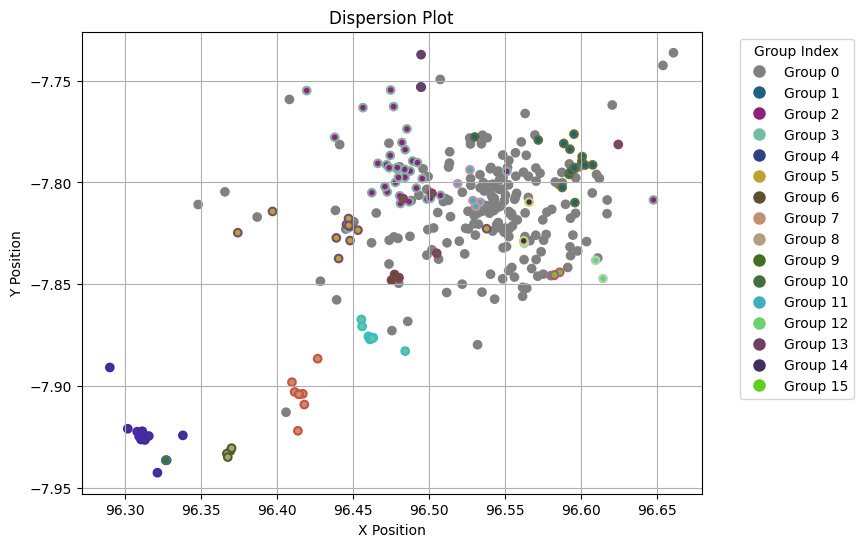

In [15]:
group = np.array(sample.iloc[:, 2].values, dtype=int)

cplt.plot_clusters(X_data, Y_data, group, scale = 30)
plt.show()


Plot DS_test

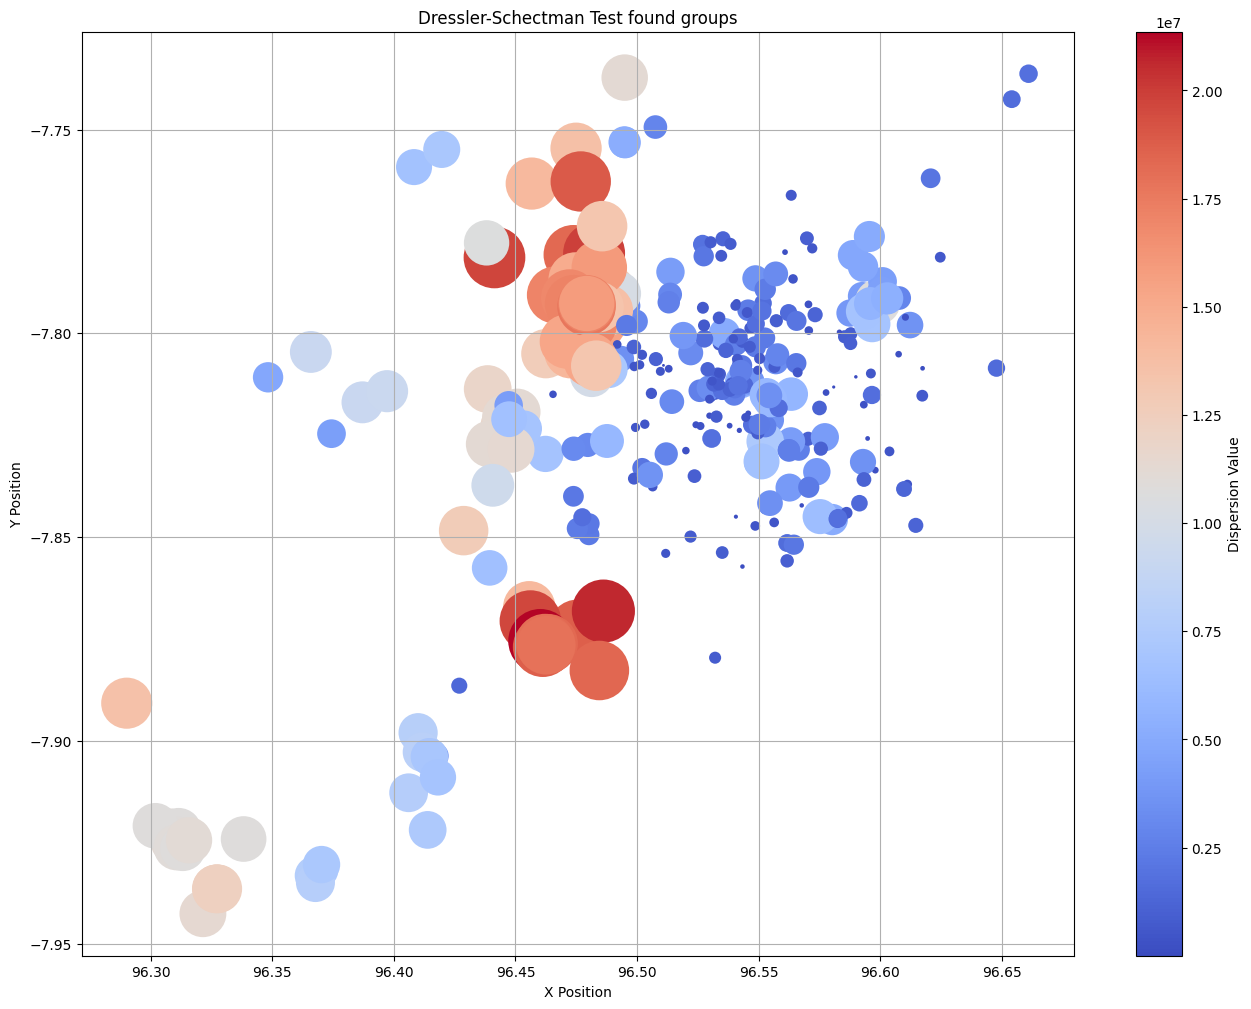

In [23]:
deltas = clustering.run_DS_test(X_data, Y_data, V_data)

cplt.plot_with_gradient(X_data, Y_data, deltas,scale=0.0001, legend='Dressler-Schectman Test found groups')
#plotDS(X_Kpc, Y_Kpc, DS_deltas, scale=0.0001)

Plot DS+

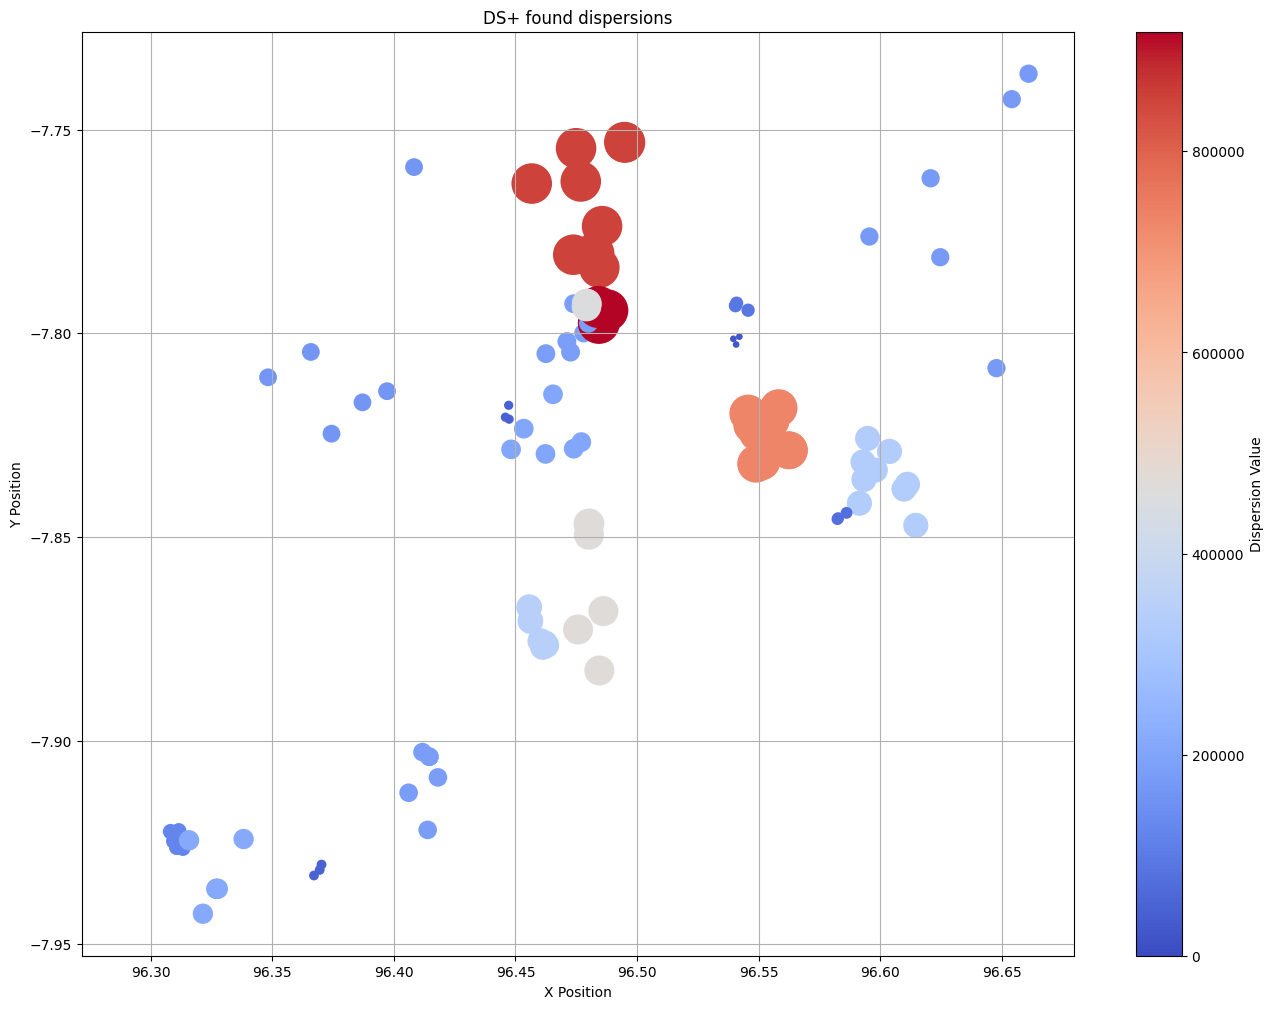

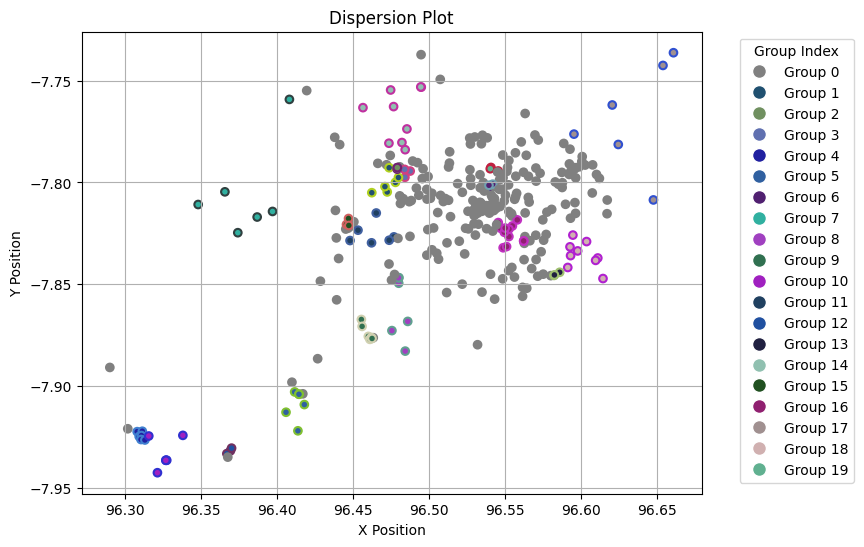

In [16]:
labels, output, clusterer = clustering.run_DSP_test(X_Kpc, Y_Kpc, V_data, Z_clus)
V_disp = output[:, 3]

colour_indexes = np.unique(labels, return_inverse=True)[1]

cplt.plot_with_gradient(X_data, Y_data, V_disp,scale=0.001, legend='DS+ found dispersions');
cplt.plot_clusters(X_data, Y_data, labels, scale=30)
plt.show()

distances, dit_comp, dist_pur, overlap, overlap_comp, overlap_pur, overlap_f1 = ctools.overlap_data(data, group, labels)

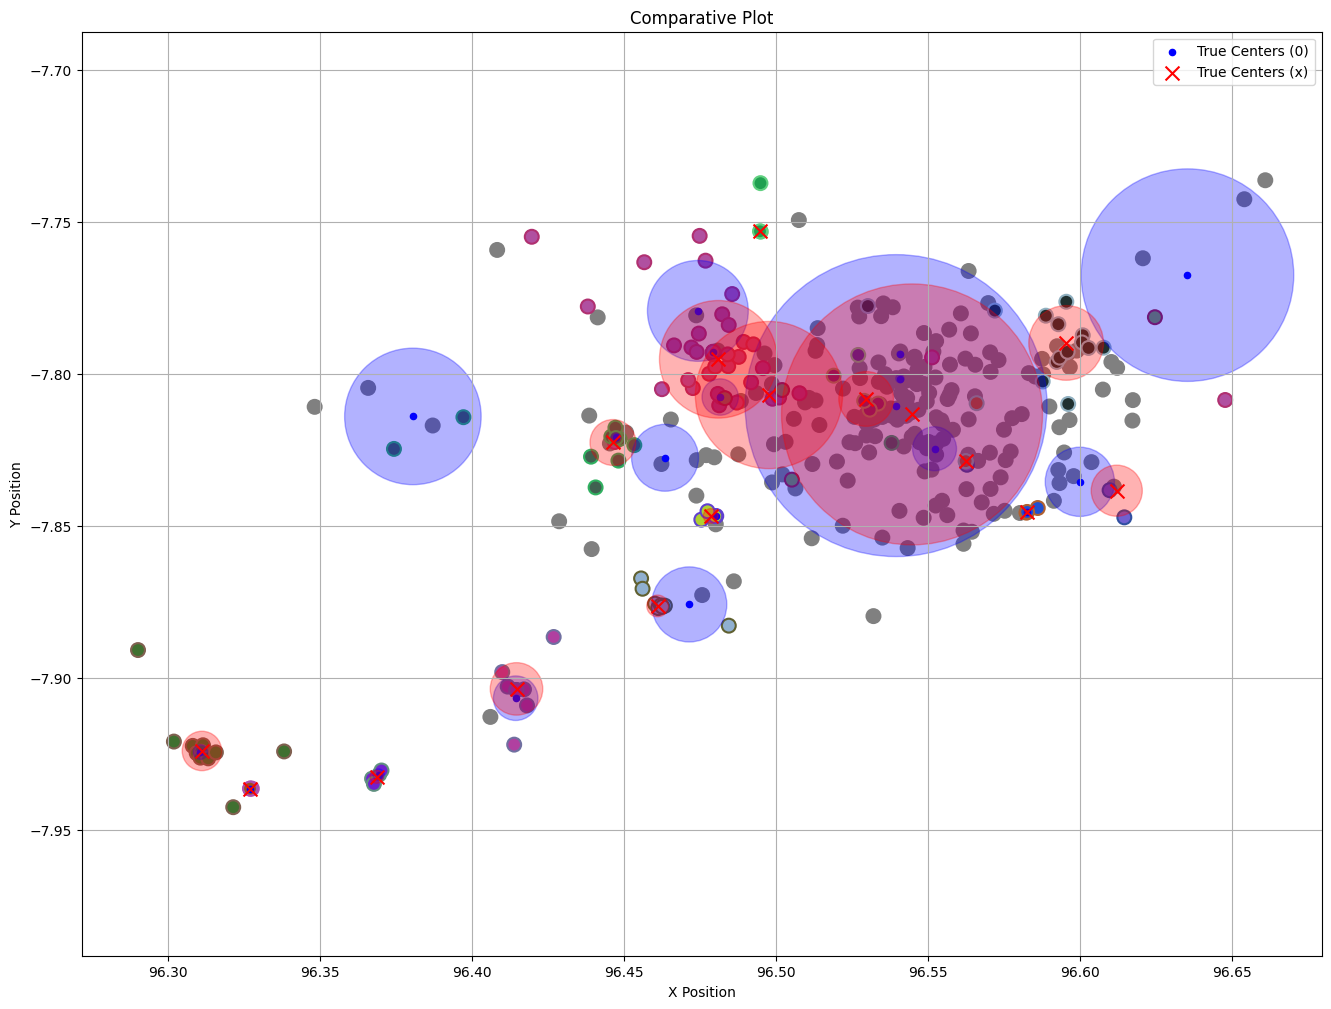

In [51]:
cplt.plot_comparative_clusters(X_data, Y_data, group, labels, alpha_pred=0.3, alpha_true= 0.3)
plt.show()

In [26]:
print("Completeness")
print(overlap_comp)

Completeness
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   1.0000  0.0000  0.0000   0.000     0.0  0.0000  0.0000  0.0000   
True 1   0.0768  0.0000  0.0000   0.000     0.0  0.0000  0.0000  0.0000   
True 2   0.1687  0.0000  0.0000   0.000     0.0  0.1402  0.0000  0.0000   
True 3   0.0000  0.0000  0.0296   0.000     0.0  0.0000  0.0000  0.0000   
True 4   0.0000  0.1377  0.0000   0.000     0.0  0.0000  0.0000  0.0000   
True 5   0.0000  0.0000  0.0000   0.000     0.0  0.0000  0.0000  0.0126   
True 6   0.0000  0.0000  0.0000   0.000     0.0  0.0000  0.8713  0.0000   
True 7   0.0000  0.0000  0.0000   0.632     0.0  0.0000  0.0000  0.0000   
True 8   0.0000  0.0000  0.0000   0.000     0.0  0.0000  0.0000  0.0000   
True 9   0.0000  0.0000  0.0000   0.000     0.0  0.0000  0.0000  0.0000   
True 10  0.6770  0.0000  0.0000   0.000     0.0  0.0368  0.0000  0.0000   
True 11  1.0000  0.0000  0.0000   0.000     0.0  0.0000  0.0000  0.0000   
True 12  0.0

In [27]:
print("Purity")
print(overlap_pur)

Purity
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   0.7133     0.0     0.0  0.0000     0.0   0.000  0.0000  0.0000   
True 1   0.0045     0.0     0.0  0.0000     0.0   0.000  0.0000  0.0000   
True 2   0.0244     0.0     0.0  0.0000     1.0   1.000  0.0000  0.0000   
True 3   0.0000     0.0     1.0  0.0000     0.0   0.000  0.0000  0.0000   
True 4   0.0000     1.0     0.0  0.0000     0.0   0.000  0.0000  0.0000   
True 5   0.0000     0.0     0.0  0.0000     0.0   0.000  0.0000  0.0059   
True 6   0.0000     0.0     0.0  0.0000     0.0   0.000  0.0212  0.0000   
True 7   0.0000     0.0     0.0  0.8787     0.0   0.000  0.0000  0.0000   
True 8   0.0000     0.0     0.0  0.0000     0.0   0.000  0.0000  0.0000   
True 9   0.0000     0.0     0.0  0.0000     0.0   0.000  0.0000  0.0000   
True 10  0.1537     0.0     0.0  0.0000     1.0   0.411  0.0000  0.0000   
True 11  0.0314     0.0     0.0  0.0000     0.0   0.000  0.0000  0.0000   
True 12  0.0000   

In [28]:
print("F1 Score")
print(overlap_f1)

F1 Score
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   0.8327     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 1   0.0085     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 2   0.0427     NaN     NaN     NaN     0.0  0.2459     NaN     NaN   
True 3      NaN     NaN  0.0576     NaN     NaN     NaN     NaN     NaN   
True 4      NaN  0.2421     NaN     NaN     NaN     NaN     NaN     NaN   
True 5      NaN     NaN     NaN     NaN     NaN     NaN     NaN  0.0081   
True 6      NaN     NaN     NaN     NaN     NaN     NaN  0.0413     NaN   
True 7      NaN     NaN     NaN  0.7352     NaN     NaN     NaN     NaN   
True 8      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 9      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 10  0.2505     NaN     NaN     NaN     0.0  0.0675     NaN     NaN   
True 11  0.0608     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 12     NaN 

In [31]:

cm = pd.crosstab(index=group, columns=labels)

matrix = ctools.matrix_as_table(cm)

# Set display options to show wide DataFrames
pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)

print(cm)

col_0  -1.0    0.0    1.0    2.0    3.0    4.0    5.0    6.0    7.0    8.0   \
row_0                                                                         
-1       155      0      1      0      0      0      1      2      4      0   
 0        14      0      0      0      0      0      0      0      0      0   
 1        23      0      0      0      0      0      5      0      0      5   
 2         4      0      0      0      0      0      0      4      0      0   
 3         8      0      0      0      3      0      0      0      0      0   
 4         4      0      0      0      0      0      0      0      2      0   
 5         4      0      0      0      0      0      0      0      0      0   
 6         0      6      2      0      0      0      0      0      0      0   
 7         1      0      0      0      0      3      0      0      0      0   
 8         0      0      0      3      0      0      0      0      0      0   
 9         2      0      0      0      0      0     

In [53]:
#COMPLETENESS

unique_true, ut_count = np.unique(group, return_counts=True)

utc_expanded = ut_count[:, np.newaxis]  # Shape (num_true, 1)-

completeness = cm/utc_expanded

c_df = ctools.matrix_as_table(completeness)

print(completeness)



col_0     -1.0    0.0       1.0    2.0       3.0    4.0       5.0       6.0   \
row_0                                                                          
-1     0.790816   0.00  0.005102    0.0  0.000000   0.00  0.005102  0.010204   
 0     0.933333   0.00  0.000000    0.0  0.000000   0.00  0.000000  0.000000   
 1     0.605263   0.00  0.000000    0.0  0.000000   0.00  0.131579  0.000000   
 2     0.500000   0.00  0.000000    0.0  0.000000   0.00  0.000000  0.500000   
 3     0.727273   0.00  0.000000    0.0  0.272727   0.00  0.000000  0.000000   
 4     0.363636   0.00  0.000000    0.0  0.000000   0.00  0.000000  0.000000   
 5     1.000000   0.00  0.000000    0.0  0.000000   0.00  0.000000  0.000000   
 6     0.000000   0.75  0.250000    0.0  0.000000   0.00  0.000000  0.000000   
 7     0.250000   0.00  0.000000    0.0  0.000000   0.75  0.000000  0.000000   
 8     0.000000   0.00  0.000000    1.0  0.000000   0.00  0.000000  0.000000   
 9     0.500000   0.00  0.000000    0.0 

In [34]:
#PURITY
unique_pred, up_count = np.unique(labels, return_counts=True)

upc_expanded = up_count[np.newaxis, :]  # Shape (num_true, 1)-

purity = cm/upc_expanded

print(purity)

col_0     -1.0    0.0       1.0    2.0    3.0    4.0       5.0       6.0   \
row_0                                                                       
-1     0.695067    0.0  0.333333    0.0    0.0    0.0  0.166667  0.333333   
 0     0.062780    0.0  0.000000    0.0    0.0    0.0  0.000000  0.000000   
 1     0.103139    0.0  0.000000    0.0    0.0    0.0  0.833333  0.000000   
 2     0.017937    0.0  0.000000    0.0    0.0    0.0  0.000000  0.666667   
 3     0.035874    0.0  0.000000    0.0    1.0    0.0  0.000000  0.000000   
 4     0.017937    0.0  0.000000    0.0    0.0    0.0  0.000000  0.000000   
 5     0.017937    0.0  0.000000    0.0    0.0    0.0  0.000000  0.000000   
 6     0.000000    1.0  0.666667    0.0    0.0    0.0  0.000000  0.000000   
 7     0.004484    0.0  0.000000    0.0    0.0    1.0  0.000000  0.000000   
 8     0.000000    0.0  0.000000    1.0    0.0    0.0  0.000000  0.000000   
 9     0.008969    0.0  0.000000    0.0    0.0    0.0  0.000000  0.000000   

In [35]:
#F1_SCORE
f1 = cmetrics.get_f1_score(completeness, purity)

print(f1)

col_0     -1.0       0.0       1.0    2.0       3.0       4.0       5.0   \
row_0                                                                      
-1     0.739857       NaN  0.010050    NaN       NaN       NaN  0.009901   
 0     0.117647       NaN       NaN    NaN       NaN       NaN       NaN   
 1     0.176245       NaN       NaN    NaN       NaN       NaN  0.227273   
 2     0.034632       NaN       NaN    NaN       NaN       NaN       NaN   
 3     0.068376       NaN       NaN    NaN  0.428571       NaN       NaN   
 4     0.034188       NaN       NaN    NaN       NaN       NaN       NaN   
 5     0.035242       NaN       NaN    NaN       NaN       NaN       NaN   
 6          NaN  0.857143  0.363636    NaN       NaN       NaN       NaN   
 7     0.008811       NaN       NaN    NaN       NaN  0.857143       NaN   
 8          NaN       NaN       NaN    1.0       NaN       NaN       NaN   
 9     0.017621       NaN       NaN    NaN       NaN       NaN       NaN   
 10    0.043

Plot GMM

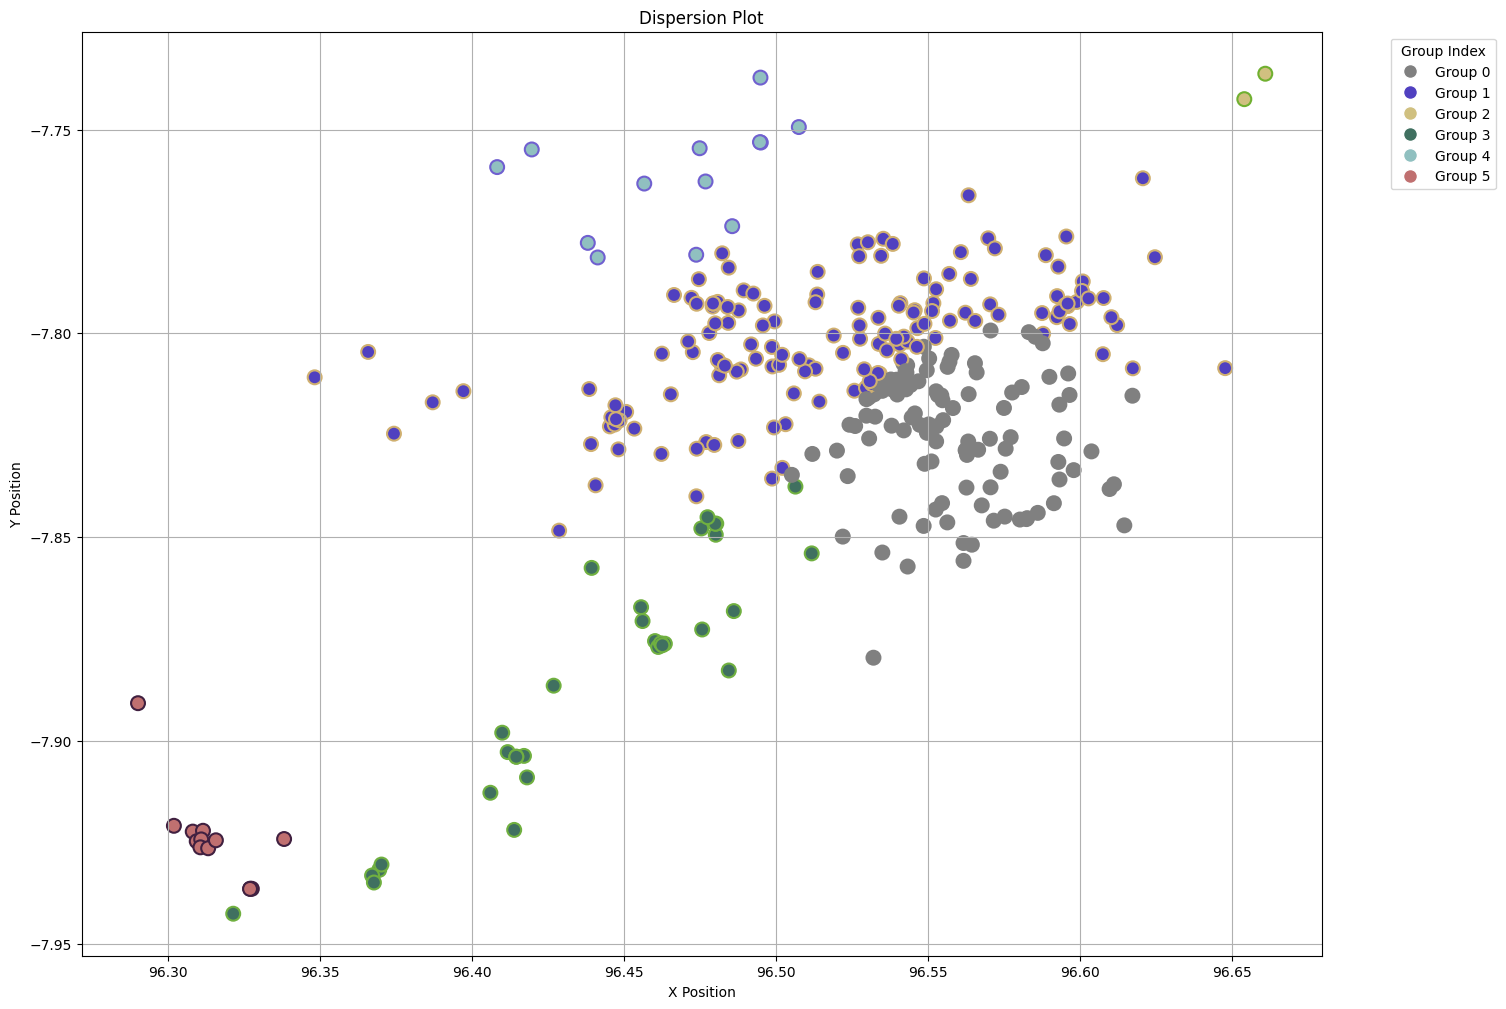

In [14]:
labels, prob, clusterer = clustering.run_GMM(data, params)

cplt.plot_clusters(X_data, Y_data, labels)
plt.show()

distances, dit_comp, dist_pur, overlap, overlap_comp, overlap_pur, overlap_f1 = print_overlaps(data, group, labels)

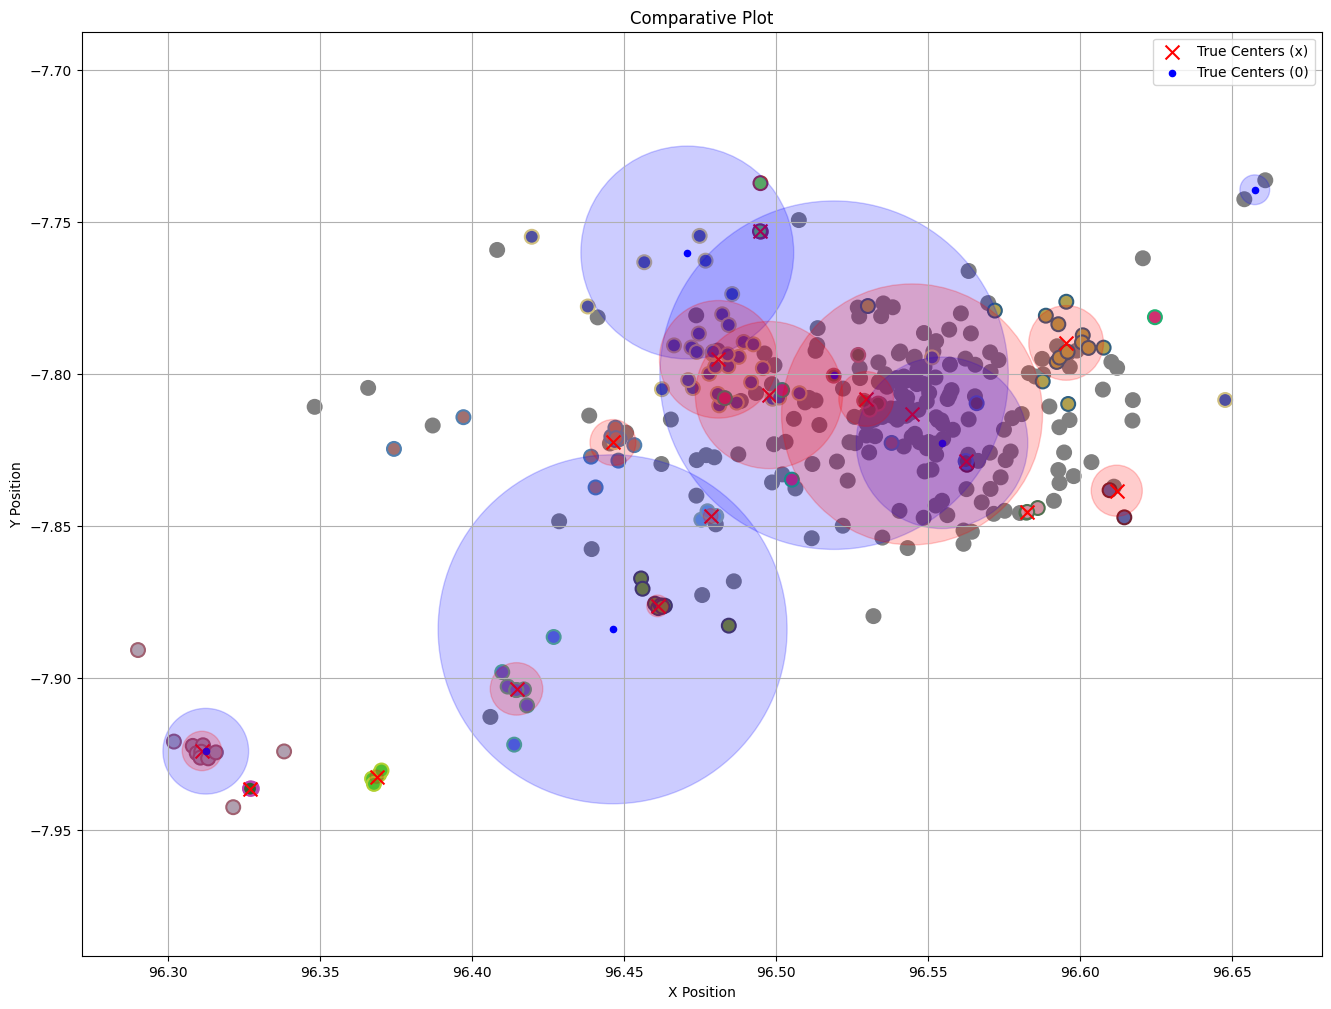

In [15]:
cplt.plot_comparative_clusters(X_data, Y_data, group, labels)
plt.show()

In [16]:
print("Completeness")
print(overlap_comp)

Completeness
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5
True 0   0.4320  0.8349     0.0  0.0000  0.0000     0.0
True 1   0.0000  0.0000     0.0  0.0000  0.0000     0.0
True 2   0.0000  0.9972     0.0  0.0000  0.3916     0.0
True 3   0.0000  0.0000     0.0  1.0000  0.0000     0.0
True 4   0.0000  0.0000     0.0  0.0000  0.0000     1.0
True 5   0.0000  0.0000     0.0  0.1671  0.0000     0.0
True 6   0.0000  0.0000     0.0  1.0000  0.0000     0.0
True 7   0.0000  0.0000     0.0  1.0000  0.0000     0.0
True 8   0.0000  0.0000     0.0  0.0000  0.0000     0.0
True 9   0.0000  0.0000     0.0  0.0000  0.0000     0.0
True 10  0.0000  1.0000     0.0  0.0000  0.0450     0.0
True 11  0.4232  1.0000     0.0  0.0000  0.0000     0.0
True 12  0.0000  0.0000     0.0  0.0000  0.0000     0.0
True 13  0.0000  1.0000     0.0  0.0000  1.0000     0.0
True 14  1.0000  1.0000     0.0  0.0000  0.0000     0.0
True 15  0.0000  0.0000     0.0  0.0000  0.0000     0.0


In [17]:
print("Purity")
print(overlap_pur)

Purity
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5
True 0   1.0000  0.4682     0.0  0.0000  0.0000  0.0000
True 1   0.0000  0.0000     0.0  0.0000  0.0000  0.0000
True 2   0.0000  0.1136     0.0  0.0000  0.1196  0.0000
True 3   0.0000  0.0000     0.0  0.0039  0.0000  0.0000
True 4   0.0000  0.0000     0.0  0.0000  0.0000  0.2118
True 5   0.0000  0.0000     0.0  0.0029  0.0000  0.0000
True 6   0.0000  0.0000     0.0  0.0018  0.0000  0.0000
True 7   0.0000  0.0000     0.0  0.0226  0.0000  0.0000
True 8   0.0000  0.0000     0.0  0.0000  0.0000  0.0000
True 9   0.0000  0.0000     0.0  0.0000  0.0000  0.0000
True 10  0.0000  0.1785     0.0  0.0000  0.0215  0.0000
True 11  0.0431  0.0247     0.0  0.0000  0.0000  0.0000
True 12  0.0000  0.0000     0.0  0.0000  0.0000  0.0000
True 13  0.0000  0.0000     0.0  0.0000  0.0000  0.0000
True 14  0.0000  0.0000     0.0  0.0000  0.0000  0.0000
True 15  0.0000  0.0000     0.0  0.0000  0.0000  0.0000


In [18]:
print("F1 Score")
print(overlap_f1)

F1 Score
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5
True 0   0.6033  0.5999     NaN     NaN     NaN     NaN
True 1      NaN     NaN     NaN     NaN     NaN     NaN
True 2      NaN  0.2039     NaN     NaN  0.1832     NaN
True 3      NaN     NaN     NaN  0.0077     NaN     NaN
True 4      NaN     NaN     NaN     NaN     NaN  0.3496
True 5      NaN     NaN     NaN  0.0057     NaN     NaN
True 6      NaN     NaN     NaN  0.0035     NaN     NaN
True 7      NaN     NaN     NaN  0.0443     NaN     NaN
True 8      NaN     NaN     NaN     NaN     NaN     NaN
True 9      NaN     NaN     NaN     NaN     NaN     NaN
True 10     NaN  0.3029     NaN     NaN  0.0291     NaN
True 11  0.0782  0.0481     NaN     NaN     NaN     NaN
True 12     NaN     NaN     NaN     NaN     NaN     NaN
True 13     NaN  0.0000     NaN     NaN  0.0000     NaN
True 14  0.0000  0.0000     NaN     NaN     NaN     NaN
True 15     NaN     NaN     NaN     NaN     NaN     NaN


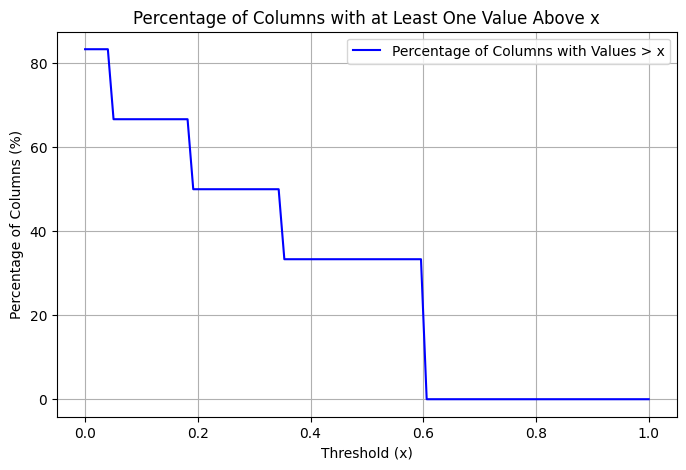

In [19]:
x_values = np.linspace(0, 1, 100)
y_values = []

# Compute the percentage of columns with at least one value above x
for x in x_values:
    count_above_x = (overlap_f1 > x).any(axis=0).sum()
    percentage = (count_above_x / overlap_f1.shape[1]) * 100
    y_values.append(percentage)

# Plot the graph
plt.figure(figsize=(8, 5))
plt.plot(x_values, y_values, label="Percentage of Columns with Values > x", color="b")
plt.xlabel("Threshold (x)")
plt.ylabel("Percentage of Columns (%)")
plt.title("Percentage of Columns with at Least One Value Above x")
plt.grid()
plt.legend()
plt.show()

Metrica de distancia haversin
Metodo para vecinos ball tree

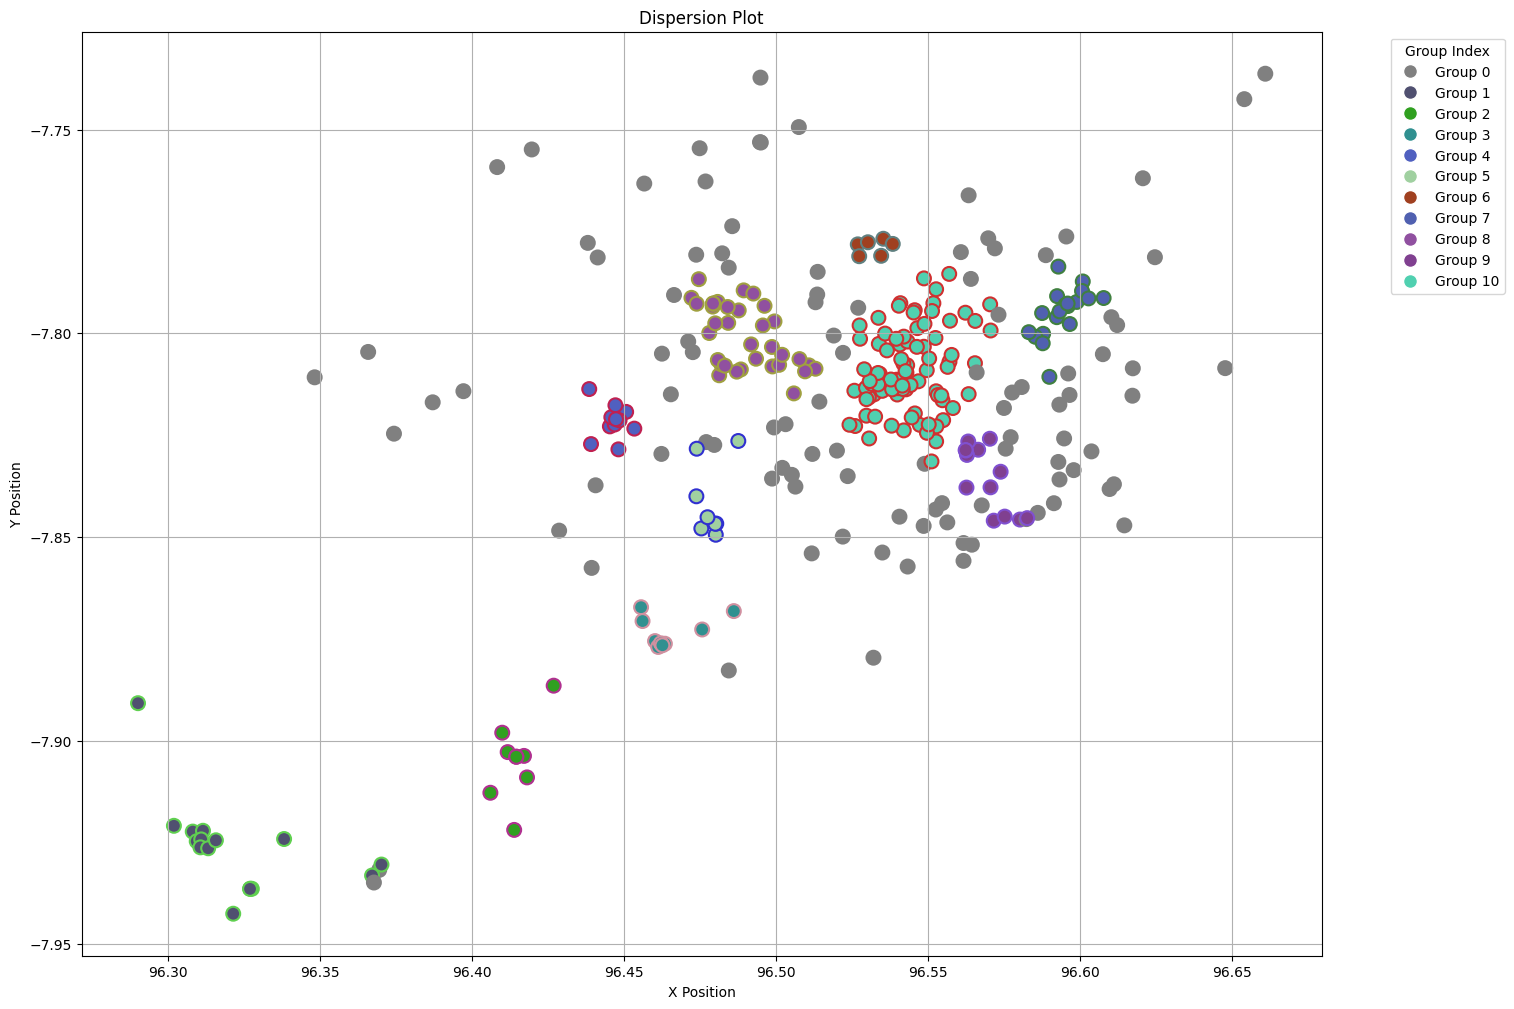

In [14]:
labels, prob, clusterer = clustering.run_HDBSCAN(data, params)

cplt.plot_clusters(X_data, Y_data, labels)
plt.show()

distances, dit_comp, dist_pur, overlap, overlap_comp, overlap_pur, overlap_f1 = ctools.overlap_data(data, group, labels)

Poner este en el psoter sin e grupo de ruido

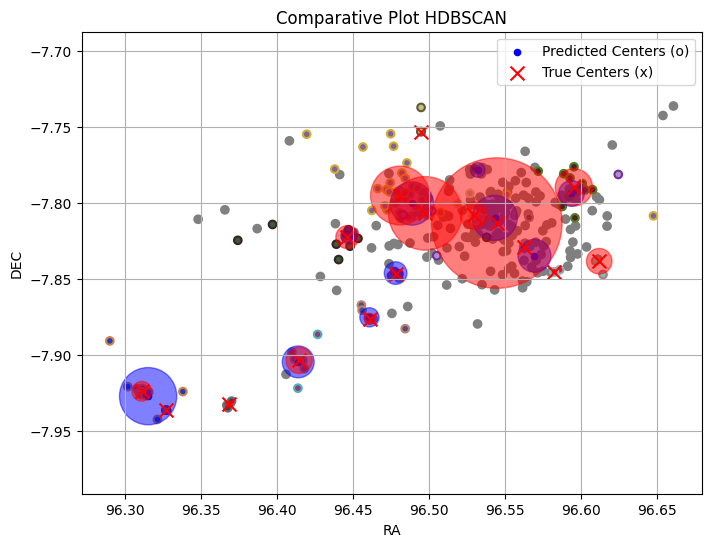

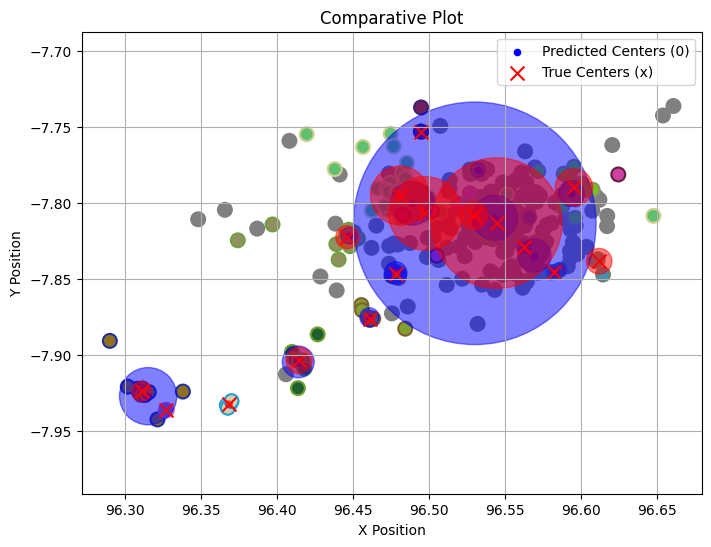

In [27]:
cplt.plot_comparative_clusters_n0(X_data, Y_data, group, labels, legend="Comparative Plot HDBSCAN", scale=30)
plt.show()
cplt.plot_comparative_clusters(X_data, Y_data, group, labels)
plt.show()

In [36]:
print("Completeness")
print(overlap_comp)

Completeness
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   1.0000     0.0     0.0     0.0  0.0000     0.0  0.0128  0.0000   
True 1   0.9629     0.0     0.0     0.0  0.0000     0.0  0.0000  0.4691   
True 2   1.0000     0.0     0.0     0.0  0.0000     0.0  0.0000  0.0000   
True 3   0.0000     0.0     0.0     1.0  0.0000     0.0  0.0000  0.0000   
True 4   0.0000     1.0     0.0     0.0  0.0000     0.0  0.0000  0.0000   
True 5   0.1337     0.0     0.0     0.0  0.5234     0.0  0.0000  0.0000   
True 6   1.0000     0.0     0.0     0.0  0.0000     1.0  0.0000  0.0000   
True 7   0.0000     0.0     1.0     0.0  0.0000     0.0  0.0000  0.0000   
True 8   0.0000     0.0     0.0     0.0  0.0000     0.0  0.0000  0.0000   
True 9   0.0000     1.0     0.0     0.0  0.0000     0.0  0.0000  0.0000   
True 10  1.0000     0.0     0.0     0.0  0.0000     0.0  0.0000  0.0000   
True 11  1.0000     0.0     0.0     0.0  0.0000     0.0  0.0000  0.0000   
True 12  0.0

In [37]:
print("Purity")
print(overlap_pur)

Purity
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   0.2894  0.0000  0.0000  0.0000     0.0  0.0000     1.0  0.0000   
True 1   0.0228  0.0000  0.0000  0.0000     0.0  0.0000     0.0  0.9839   
True 2   0.0588  0.0000  0.0000  0.0000     0.0  0.0000     0.0  0.0000   
True 3   0.0000  0.0000  0.0000  0.3196     0.0  0.0000     0.0  0.0000   
True 4   0.0000  0.1187  0.0000  0.0000     0.0  0.0000     0.0  0.0000   
True 5   0.0012  0.0000  0.0000  0.0000     1.0  0.0000     0.0  0.0000   
True 6   0.0009  0.0000  0.0000  0.0000     0.0  0.1054     0.0  0.0000   
True 7   0.0000  0.0000  0.6788  0.0000     0.0  0.0000     0.0  0.0000   
True 8   0.0000  0.0000  0.0000  0.0000     0.0  0.0000     0.0  0.0000   
True 9   0.0000  0.0002  0.0000  0.0000     0.0  0.0000     0.0  0.0000   
True 10  0.0921  0.0000  0.0000  0.0000     0.0  0.0000     0.0  0.0000   
True 11  0.0127  0.0000  0.0000  0.0000     0.0  0.0000     0.0  0.0000   
True 12  0.0011  0

In [38]:
print("F1 Score")
print(overlap_f1)

F1 Score
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   0.4489     NaN     NaN     NaN     NaN     NaN  0.0252     NaN   
True 1   0.0446     NaN     NaN     NaN     NaN     NaN     NaN  0.6353   
True 2   0.1110     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 3      NaN     NaN     NaN  0.4844     NaN     NaN     NaN     NaN   
True 4      NaN  0.2123     NaN     NaN     NaN     NaN     NaN     NaN   
True 5   0.0024     NaN     NaN     NaN  0.6871     NaN     NaN     NaN   
True 6   0.0018     NaN     NaN     NaN     NaN  0.1907     NaN     NaN   
True 7      NaN     NaN  0.8087     NaN     NaN     NaN     NaN     NaN   
True 8      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 9      NaN  0.0003     NaN     NaN     NaN     NaN     NaN     NaN   
True 10  0.1686     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 11  0.0251     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 12  0.0021 

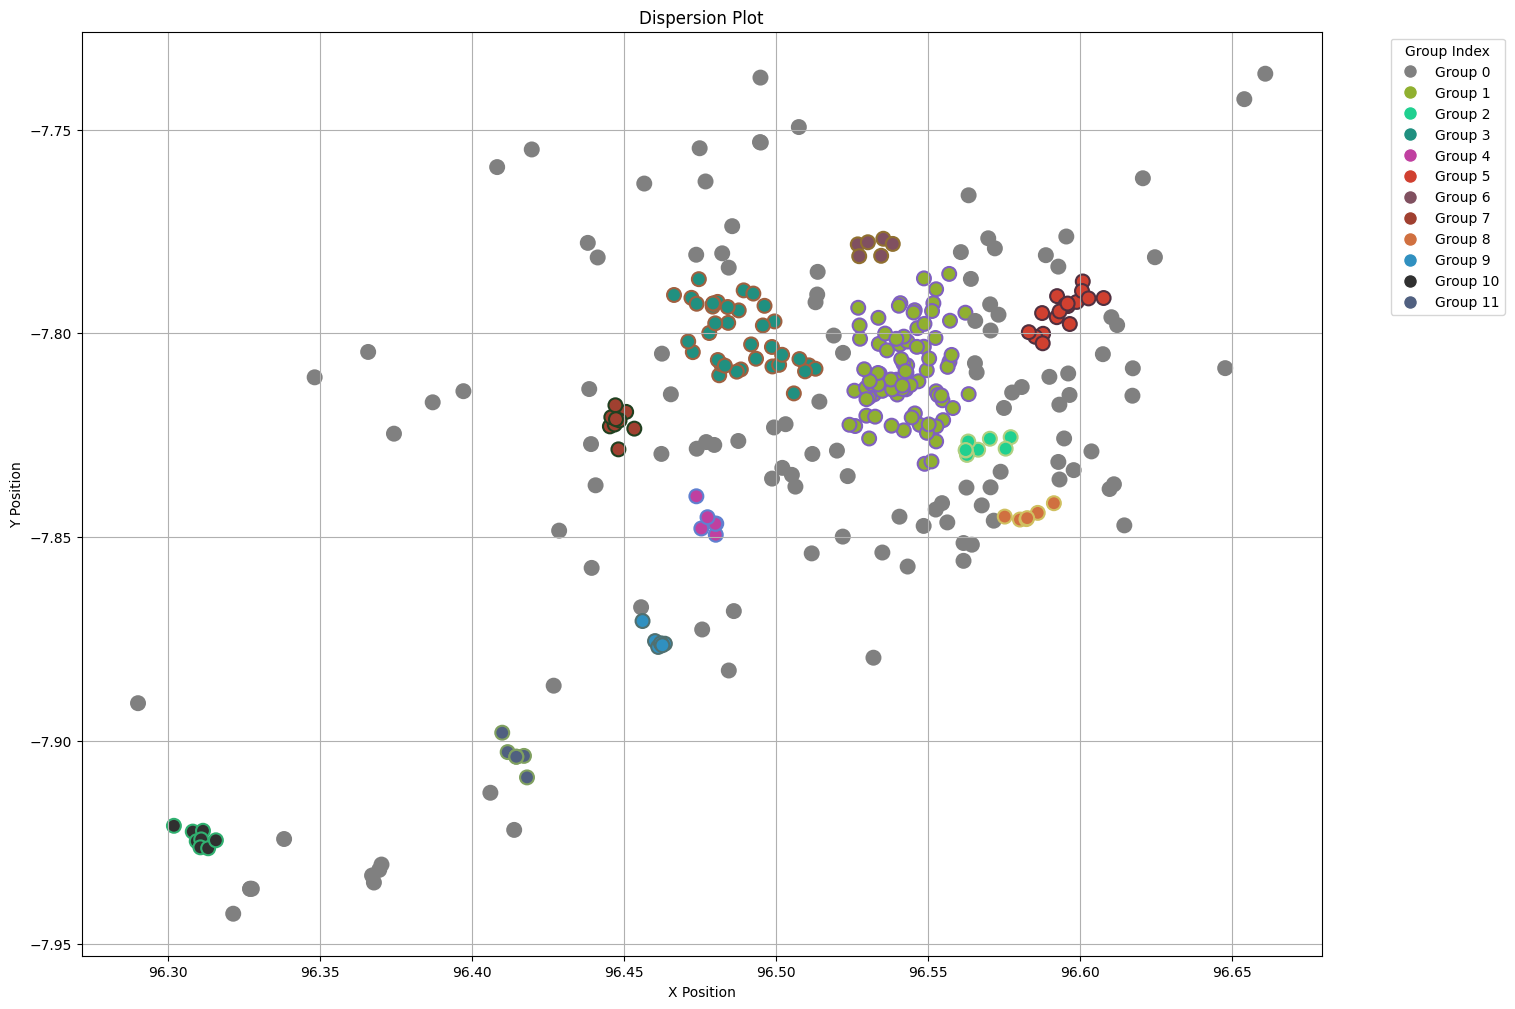

In [39]:
labels, prob, clusterer = clustering.run_DBSCAN(data, params)

cplt.plot_clusters(X_data, Y_data, labels)
plt.show()

distances, dit_comp, dist_pur, overlap, overlap_comp, overlap_pur, overlap_f1 = print_overlaps(data, group, labels)

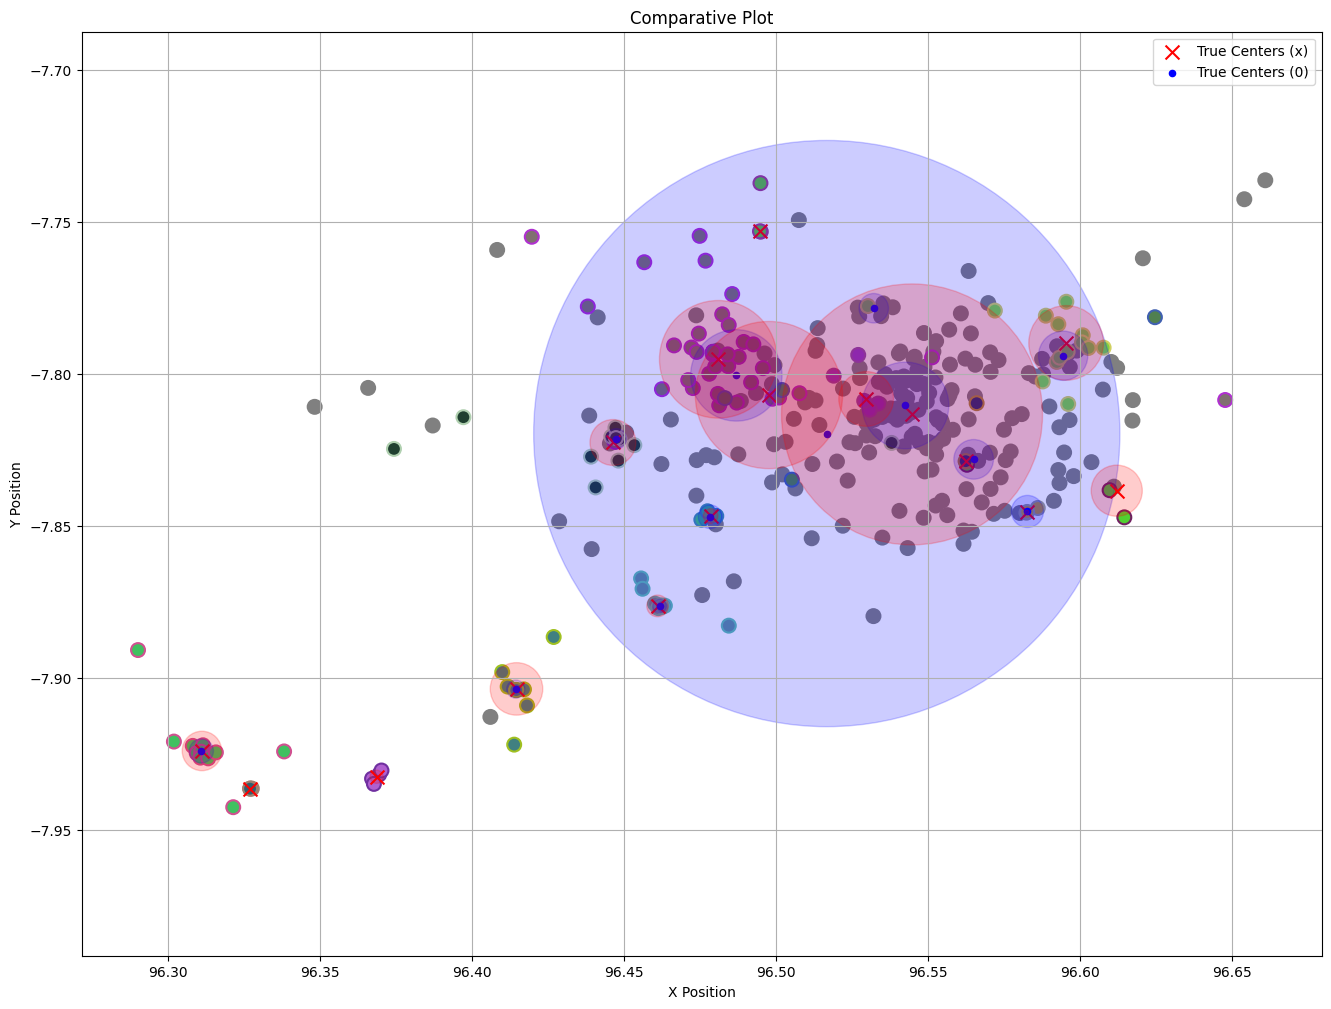

In [40]:
cplt.plot_comparative_clusters(X_data, Y_data, group, labels)
plt.show()

In [41]:
print("Completeness")
print(overlap_comp)

Completeness
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   1.0000  0.1103  0.0231  0.0000     0.0  0.0000  0.0128   0.000   
True 1   0.9998  0.0000  0.0000  0.0000     0.0  0.4341  0.0000   0.000   
True 2   1.0000  0.0000  0.0000  0.5358     0.0  0.0000  0.0000   0.000   
True 3   1.0000  0.0000  0.0000  0.0000     0.0  0.0000  0.0000   0.000   
True 4   0.0000  0.0000  0.0000  0.0000     0.0  0.0000  0.0000   0.000   
True 5   1.0000  0.0000  0.0000  0.0000     0.0  0.0000  0.0000   0.199   
True 6   1.0000  0.0000  0.0000  0.0000     1.0  0.0000  0.0000   0.000   
True 7   0.0000  0.0000  0.0000  0.0000     0.0  0.0000  0.0000   0.000   
True 8   0.0000  0.0000  0.0000  0.0000     0.0  0.0000  0.0000   0.000   
True 9   0.0000  0.0000  0.0000  0.0000     0.0  0.0000  0.0000   0.000   
True 10  1.0000  0.0000  0.0000  0.3518     0.0  0.0000  0.0000   0.000   
True 11  1.0000  0.5116  0.0000  0.0000     0.0  0.0000  0.0000   0.000   
True 12  0.4

In [42]:
print("Purity")
print(overlap_pur)

Purity
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   0.1982  1.0000  1.0000  0.0000  0.0000  0.0000     1.0     0.0   
True 1   0.0162  0.0000  0.0000  0.0000  0.0000  0.9976     0.0     0.0   
True 2   0.0402  0.0000  0.0000  0.8866  0.0000  0.0000     0.0     0.0   
True 3   0.0014  0.0000  0.0000  0.0000  0.0000  0.0000     0.0     0.0   
True 4   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000     0.0     0.0   
True 5   0.0061  0.0000  0.0000  0.0000  0.0000  0.0000     0.0     1.0   
True 6   0.0006  0.0000  0.0000  0.0000  0.3865  0.0000     0.0     0.0   
True 7   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000     0.0     0.0   
True 8   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000     0.0     0.0   
True 9   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000     0.0     0.0   
True 10  0.0631  0.0000  0.0000  0.9122  0.0000  0.0000     0.0     0.0   
True 11  0.0087  0.2039  0.0000  0.0000  0.0000  0.0000     0.0     0.0   
True 12  0.0033  0

In [43]:
print("F1 Score")
print(overlap_f1)

F1 Score
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   0.3308  0.1987  0.0451     NaN     NaN     NaN  0.0252     NaN   
True 1   0.0319     NaN     NaN     NaN     NaN   0.605     NaN     NaN   
True 2   0.0774     NaN     NaN  0.6679     NaN     NaN     NaN     NaN   
True 3   0.0027     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 4      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 5   0.0122     NaN     NaN     NaN     NaN     NaN     NaN  0.3319   
True 6   0.0013     NaN     NaN     NaN  0.5575     NaN     NaN     NaN   
True 7      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 8      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 9      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 10  0.1186     NaN     NaN  0.5077     NaN     NaN     NaN     NaN   
True 11  0.0173  0.2916     NaN     NaN     NaN     NaN     NaN     NaN   
True 12  0.0065 

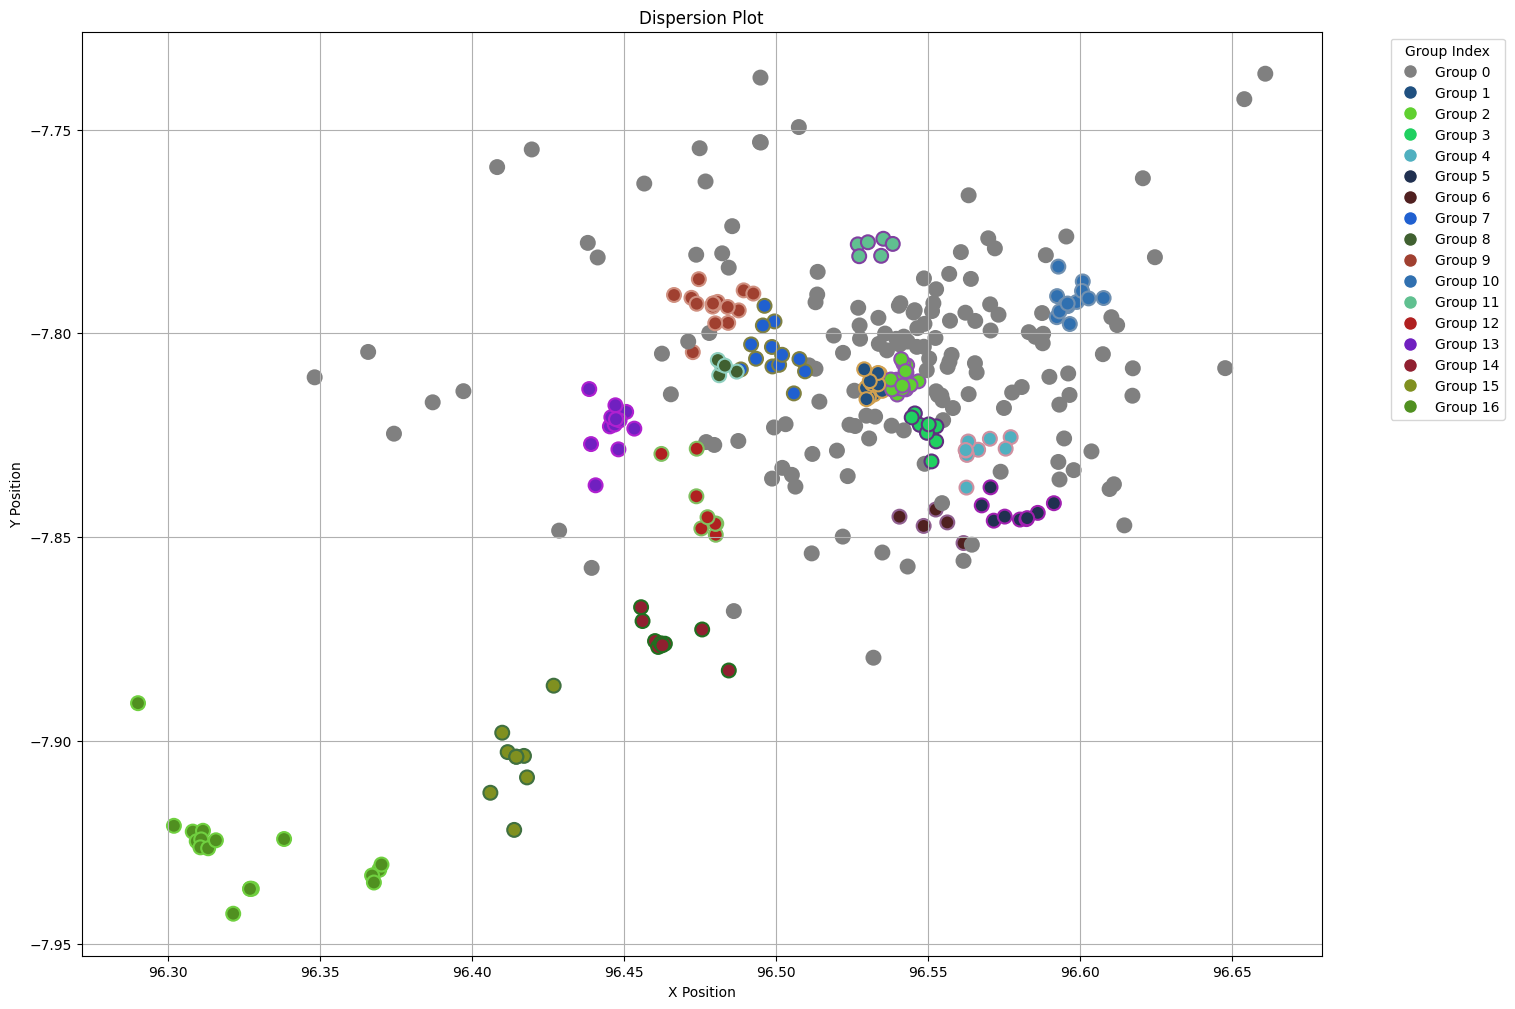

In [44]:
labels, prob, clusterer = clustering.run_OPTICS(data, params)

cplt.plot_clusters(X_data, Y_data, labels)
plt.show()

distances, dit_comp, dist_pur, overlap, overlap_comp, overlap_pur, overlap_f1 = print_overlaps(data, group, labels)

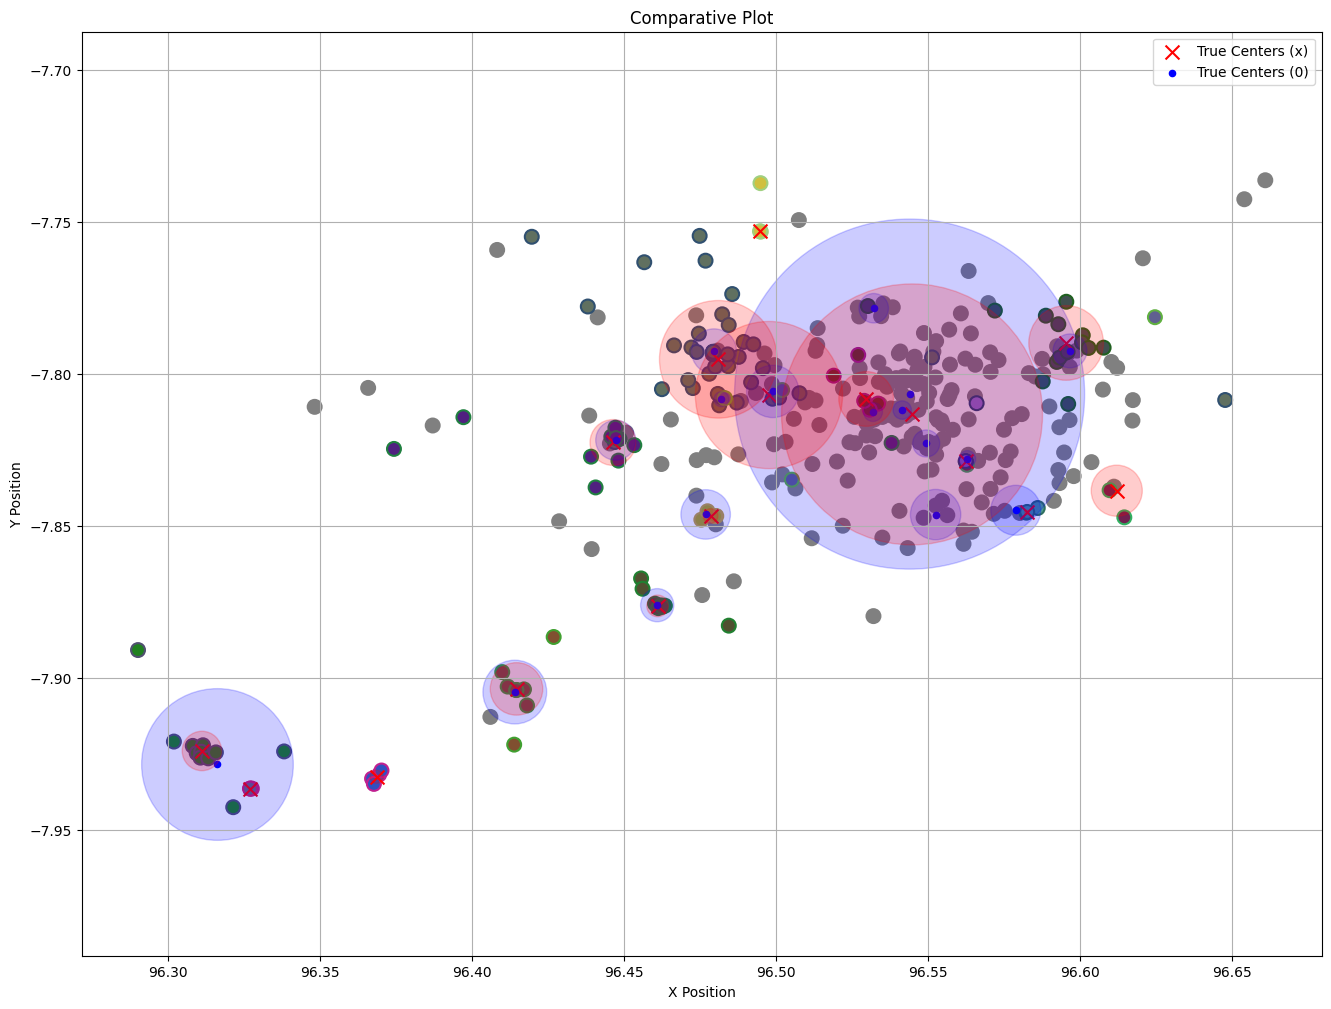

In [45]:
cplt.plot_comparative_clusters(X_data, Y_data, group, labels)
plt.show()

In [46]:
print("Completeness")
print(overlap_comp)

Completeness
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   1.0000  0.0053   0.005  0.0108   0.004  0.0081  0.0372  0.0093   
True 1   0.6526  0.0000   0.000  0.0000   0.000  0.0000  0.0000  0.0000   
True 2   0.2659  0.0000   0.000  0.0000   0.000  0.0000  0.0000  0.0694   
True 3   0.0000  0.0000   0.000  0.0000   0.000  0.0000  0.0000  0.0000   
True 4   0.0000  0.0000   0.000  0.0000   0.000  0.0000  0.0000  0.0000   
True 5   0.0000  0.0000   0.000  0.0000   0.000  0.0000  0.0000  0.0000   
True 6   0.0000  0.0000   0.000  0.0000   0.000  0.0000  0.0000  0.0000   
True 7   0.0000  0.0000   0.000  0.0000   0.000  0.0000  0.0000  0.0000   
True 8   0.0000  0.0000   0.000  0.0000   0.000  0.0000  0.0000  0.0000   
True 9   0.0000  0.0000   0.000  0.0000   0.000  0.0000  0.0000  0.0000   
True 10  0.7498  0.0000   0.000  0.0000   0.000  0.0000  0.0000  0.1264   
True 11  1.0000  0.1214   0.000  0.0000   0.000  0.0000  0.0000  0.0000   
True 12  0.0

In [47]:
print("Purity")
print(overlap_pur)

Purity
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   0.5558     1.0     1.0     1.0  1.0000  0.2199     1.0  0.2311   
True 1   0.0297     0.0     0.0     0.0  0.0000  0.0000     0.0  0.0000   
True 2   0.0300     0.0     0.0     0.0  0.0000  0.0000     0.0  0.3504   
True 3   0.0000     0.0     0.0     0.0  0.0000  0.0000     0.0  0.0000   
True 4   0.0000     0.0     0.0     0.0  0.0000  0.0000     0.0  0.0000   
True 5   0.0000     0.0     0.0     0.0  0.0000  0.0000     0.0  0.0000   
True 6   0.0000     0.0     0.0     0.0  0.0000  0.0000     0.0  0.0000   
True 7   0.0000     0.0     0.0     0.0  0.0000  0.0000     0.0  0.0000   
True 8   0.0000     0.0     0.0     0.0  0.0000  0.0000     0.0  0.0000   
True 9   0.0000     0.0     0.0     0.0  0.0000  0.0000     0.0  0.0000   
True 10  0.1326     0.0     0.0     0.0  0.0000  0.0000     0.0  1.0000   
True 11  0.0244     1.0     0.0     0.0  0.0000  0.0000     0.0  0.0000   
True 12  0.0000   

In [48]:
print("F1 Score")
print(overlap_f1)

F1 Score
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   0.7145  0.0106  0.0099  0.0213  0.0080  0.0155  0.0718  0.0179   
True 1   0.0568     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 2   0.0539     NaN     NaN     NaN     NaN     NaN     NaN  0.1158   
True 3      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 4      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 5      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 6      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 7      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 8      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 9      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 10  0.2254     NaN     NaN     NaN     NaN     NaN     NaN  0.2244   
True 11  0.0477  0.2166     NaN     NaN     NaN     NaN     NaN     NaN   
True 12     NaN 

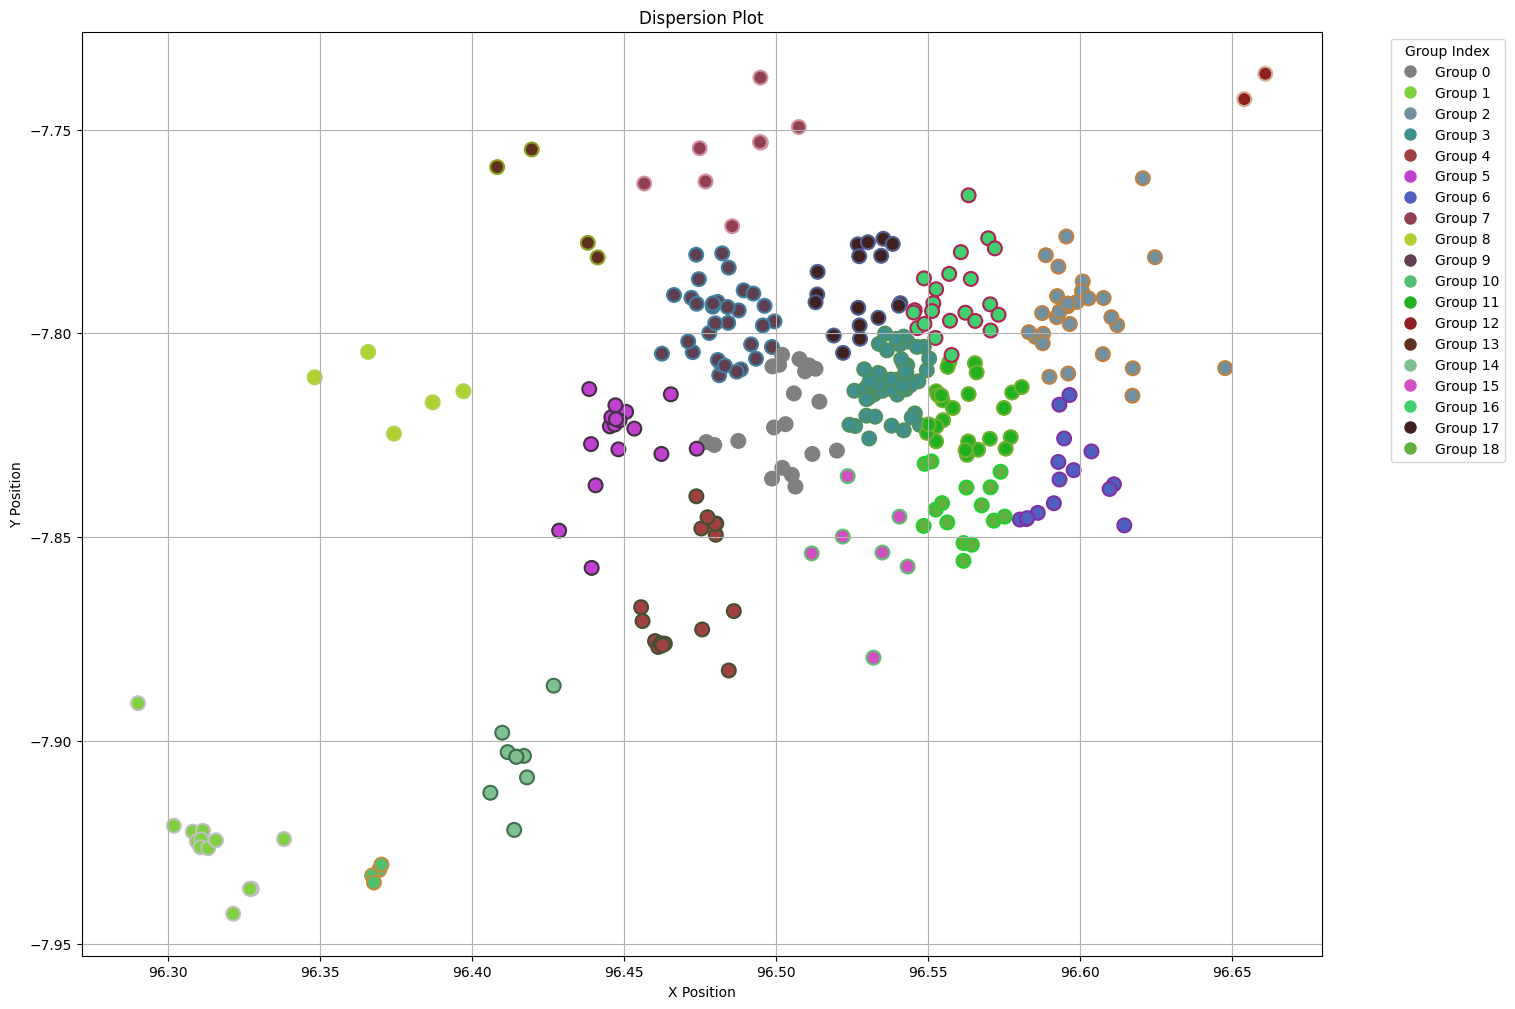

In [49]:
labels, prob, clusterer = clustering.run_Kmeans(data, params)

cplt.plot_clusters(X_data, Y_data, labels)
plt.show()

distances, dit_comp, dist_pur, overlap, overlap_comp, overlap_pur, overlap_f1 = print_overlaps(data, group, labels)

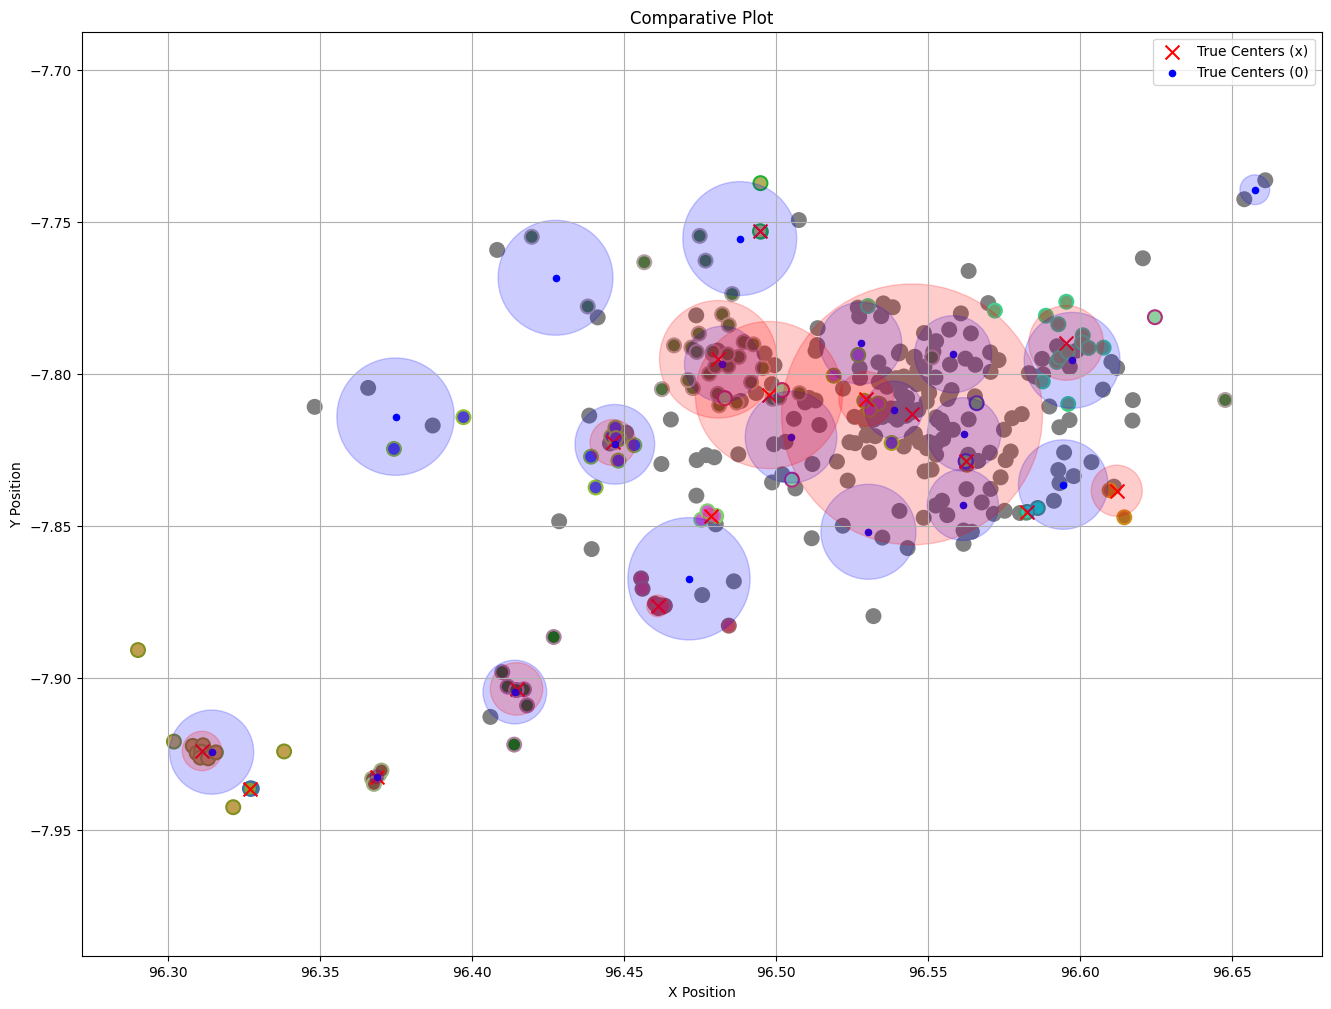

In [50]:
cplt.plot_comparative_clusters(X_data, Y_data, group, labels)
plt.show()

In [51]:
print("Completeness")
print(overlap_comp)

Completeness
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   0.0695     0.0  0.0060  0.0486  0.0000     0.0  0.0050     0.0   
True 1   0.0000     0.0  0.9062  0.0000  0.0000     0.0  0.0000     0.0   
True 2   0.0000     0.0  0.0000  0.0000  0.0000     0.0  0.0000     0.0   
True 3   0.0000     0.0  0.0000  0.0000  1.0000     0.0  0.0000     0.0   
True 4   0.0000     1.0  0.0000  0.0000  0.0000     0.0  0.0000     0.0   
True 5   0.0000     0.0  0.0000  0.0000  0.0000     1.0  0.0000     0.0   
True 6   0.0000     0.0  0.0000  0.0000  0.0841     0.0  0.0000     0.0   
True 7   0.0000     0.0  0.0000  0.0000  0.0000     0.0  0.0000     0.0   
True 8   0.0000     0.0  0.0000  0.0000  0.0000     0.0  0.0000     0.0   
True 9   0.0000     0.0  0.0000  0.0000  0.0000     0.0  0.0000     0.0   
True 10  0.3062     0.0  0.0000  0.0000  0.0000     0.0  0.0000     0.0   
True 11  0.0000     0.0  0.0000  0.3750  0.0000     0.0  0.0000     0.0   
True 12  0.0

In [52]:
print("Purity")
print(overlap_pur)

Purity
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   0.5641  0.0000  0.0443  1.0000  0.0000  0.0000  0.0428  0.0000   
True 1   0.0000  0.0000  0.5498  0.0000  0.0000  0.0000  0.0000  0.0000   
True 2   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
True 3   0.0000  0.0000  0.0000  0.0000  0.0314  0.0000  0.0000  0.0000   
True 4   0.0000  0.2197  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
True 5   0.0000  0.0000  0.0000  0.0000  0.0000  0.3313  0.0000  0.0000   
True 6   0.0000  0.0000  0.0000  0.0000  0.0012  0.0000  0.0000  0.0000   
True 7   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
True 8   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
True 9   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
True 10  0.7909  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
True 11  0.0000  0.0000  0.0000  0.3394  0.0000  0.0000  0.0000  0.0000   
True 12  0.0000  0

In [53]:
print("F1 Score")
print(overlap_f1)

F1 Score
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   0.1237     NaN  0.0106  0.0926     NaN     NaN  0.0090     NaN   
True 1      NaN     NaN  0.6844     NaN     NaN     NaN     NaN     NaN   
True 2      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 3      NaN     NaN     NaN     NaN  0.0610     NaN     NaN     NaN   
True 4      NaN  0.3602     NaN     NaN     NaN     NaN     NaN     NaN   
True 5      NaN     NaN     NaN     NaN     NaN  0.4978     NaN     NaN   
True 6      NaN     NaN     NaN     NaN  0.0024     NaN     NaN     NaN   
True 7      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 8      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 9      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 10  0.4415     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 11     NaN     NaN     NaN  0.3563     NaN     NaN     NaN     NaN   
True 12     NaN 

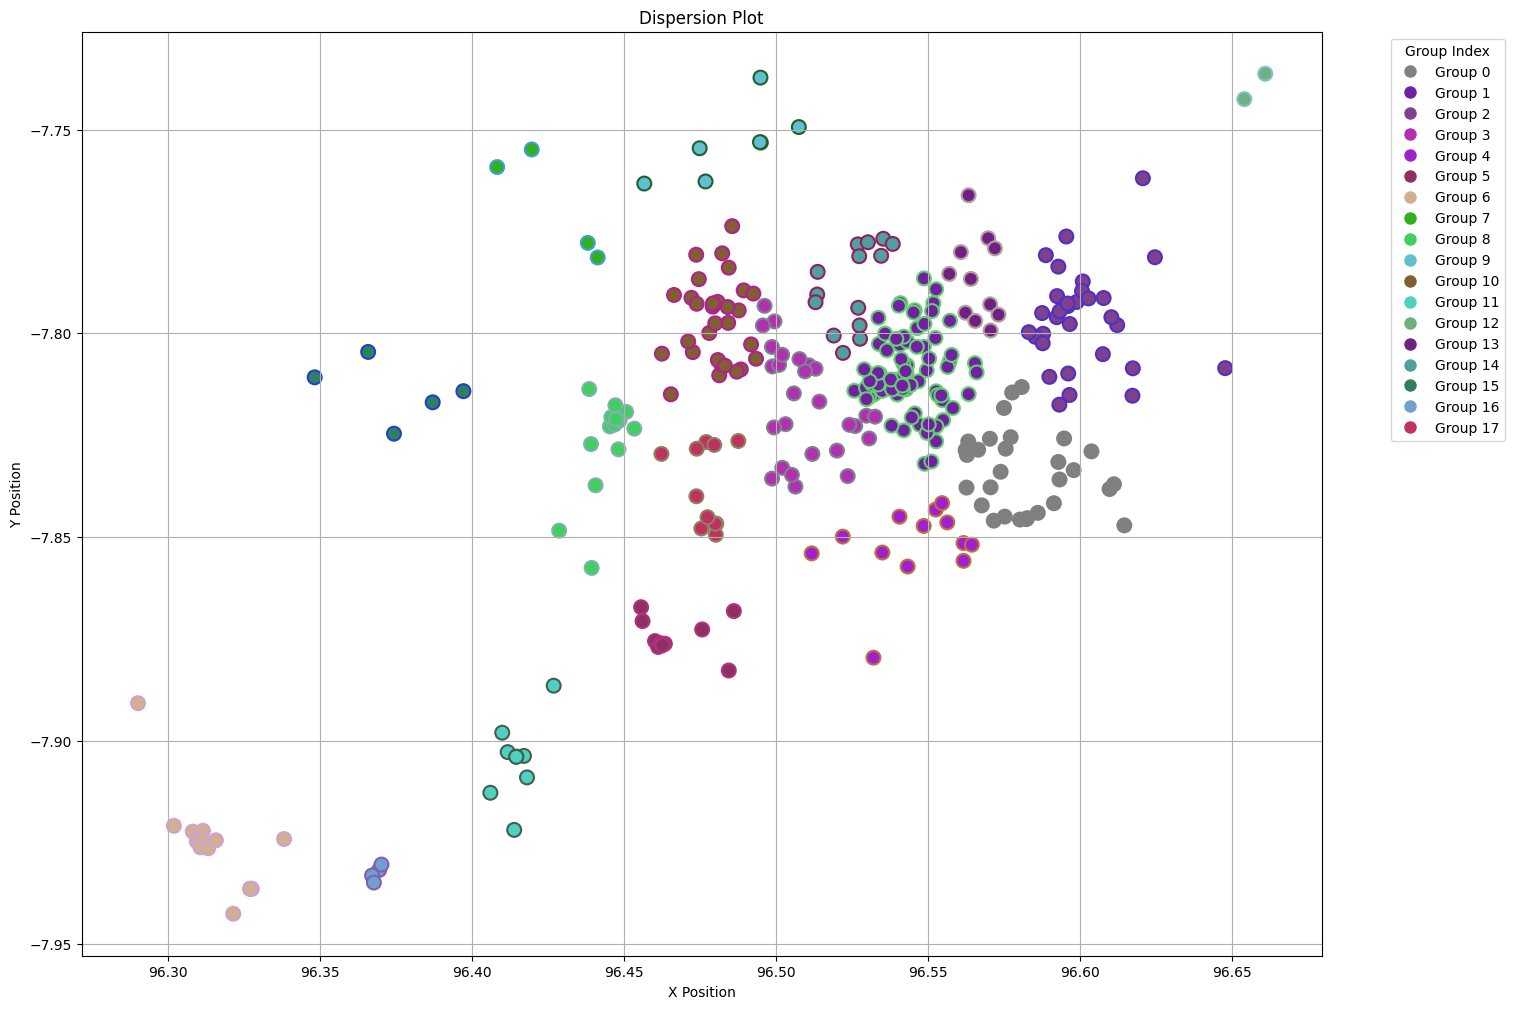

In [54]:
labels, prob, clusterer = clustering.run_Aglomerative_Clustering(data, params)


cplt.plot_clusters(X_data, Y_data, labels)
plt.show()

distances, dit_comp, dist_pur, overlap, overlap_comp, overlap_pur, overlap_f1 = print_overlaps(data, group, labels)

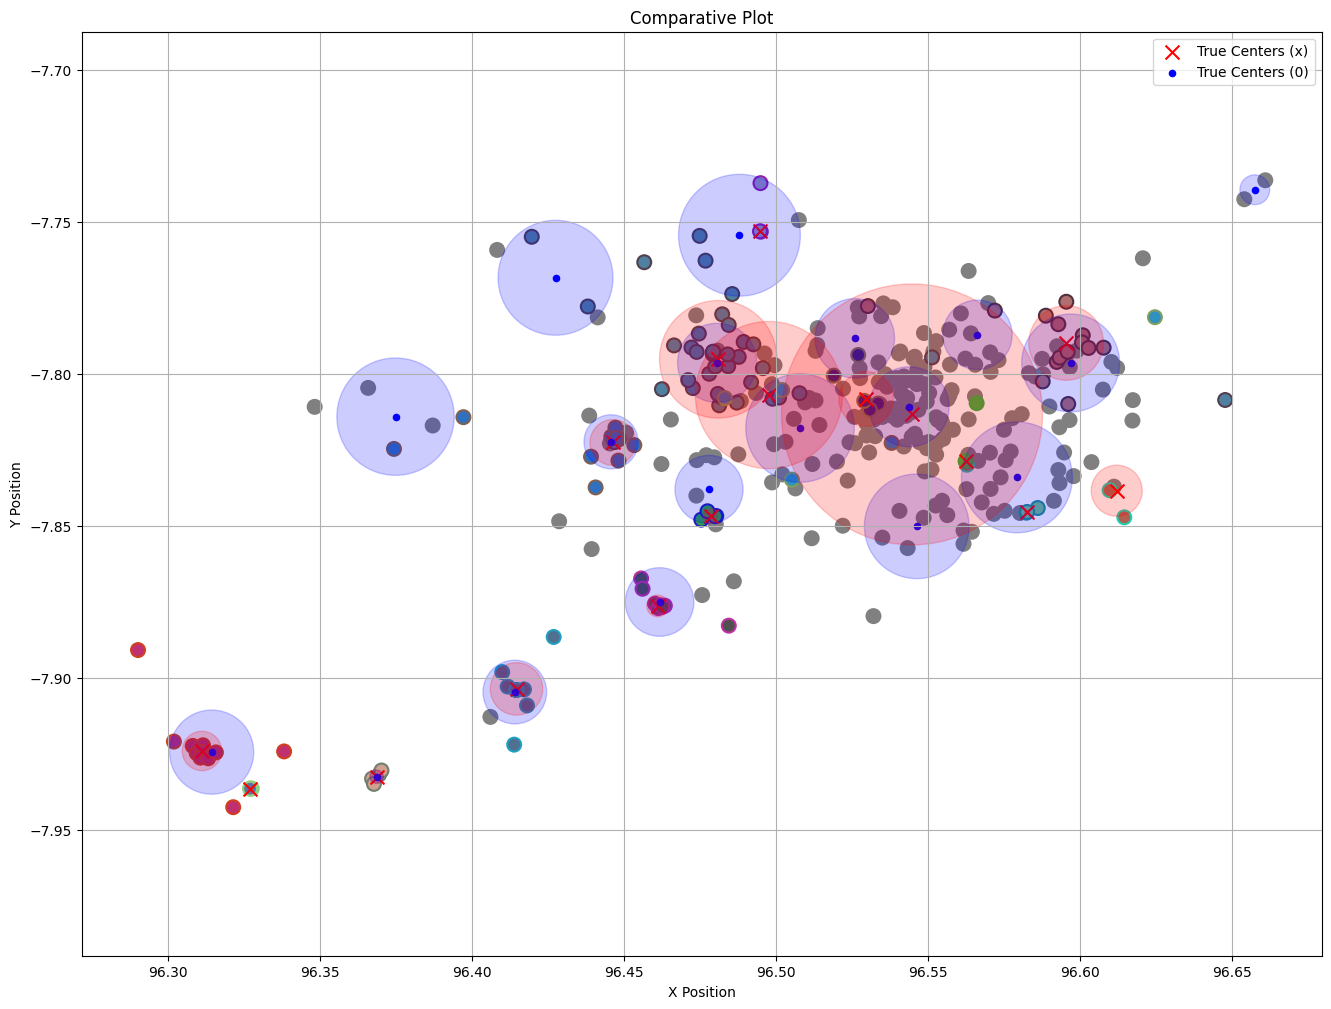

In [55]:
cplt.plot_comparative_clusters(X_data, Y_data, group, labels)
plt.show()

In [56]:
print("Completeness")
print(overlap_comp)

Completeness
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   0.0989  0.0939  0.0093  0.1145  0.1096     0.0     0.0     0.0   
True 1   0.0000  0.0000  0.8906  0.0000  0.0000     0.0     0.0     0.0   
True 2   0.0000  0.0000  0.0000  0.0143  0.0000     0.0     0.0     0.0   
True 3   0.0000  0.0000  0.0000  0.0000  0.0000     1.0     0.0     0.0   
True 4   0.0000  0.0000  0.0000  0.0000  0.0000     0.0     1.0     0.0   
True 5   0.0000  0.0000  0.0000  0.0000  0.0000     0.0     0.0     0.0   
True 6   0.0000  0.0000  0.0000  0.0000  0.0000     0.0     0.0     0.0   
True 7   0.0000  0.0000  0.0000  0.0000  0.0000     0.0     0.0     0.0   
True 8   0.0000  0.0000  0.0000  0.0000  0.0000     0.0     0.0     0.0   
True 9   0.0000  0.0000  0.0000  0.0000  0.0000     0.0     0.0     0.0   
True 10  0.0000  0.0000  0.0000  0.4052  0.0000     0.0     0.0     0.0   
True 11  0.0000  0.3469  0.0000  0.0958  0.0000     0.0     0.0     0.0   
True 12  0.0

In [57]:
print("Purity")
print(overlap_pur)

Purity
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   0.5474  1.0000  0.0659  0.6617  0.6805  0.0000  0.0000     0.0   
True 1   0.0000  0.0000  0.5179  0.0000  0.0000  0.0000  0.0000     0.0   
True 2   0.0000  0.0000  0.0000  0.0168  0.0000  0.0000  0.0000     0.0   
True 3   0.0000  0.0000  0.0000  0.0000  0.0000  0.0998  0.0000     0.0   
True 4   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.2197     0.0   
True 5   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000     0.0   
True 6   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000     0.0   
True 7   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000     0.0   
True 8   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000     0.0   
True 9   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000     0.0   
True 10  0.0000  0.0000  0.0000  0.7454  0.0000  0.0000  0.0000     0.0   
True 11  0.0000  0.1623  0.0000  0.0243  0.0000  0.0000  0.0000     0.0   
True 12  0.0000  0

In [58]:
print("F1 Score")
print(overlap_f1)

F1 Score
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   0.1675  0.1718  0.0163  0.1952  0.1887     NaN     NaN     NaN   
True 1      NaN     NaN  0.6550     NaN     NaN     NaN     NaN     NaN   
True 2      NaN     NaN     NaN  0.0155     NaN     NaN     NaN     NaN   
True 3      NaN     NaN     NaN     NaN     NaN  0.1814     NaN     NaN   
True 4      NaN     NaN     NaN     NaN     NaN     NaN  0.3602     NaN   
True 5      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 6      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 7      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 8      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 9      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 10     NaN     NaN     NaN  0.5250     NaN     NaN     NaN     NaN   
True 11     NaN  0.2212     NaN  0.0388     NaN     NaN     NaN     NaN   
True 12     NaN 

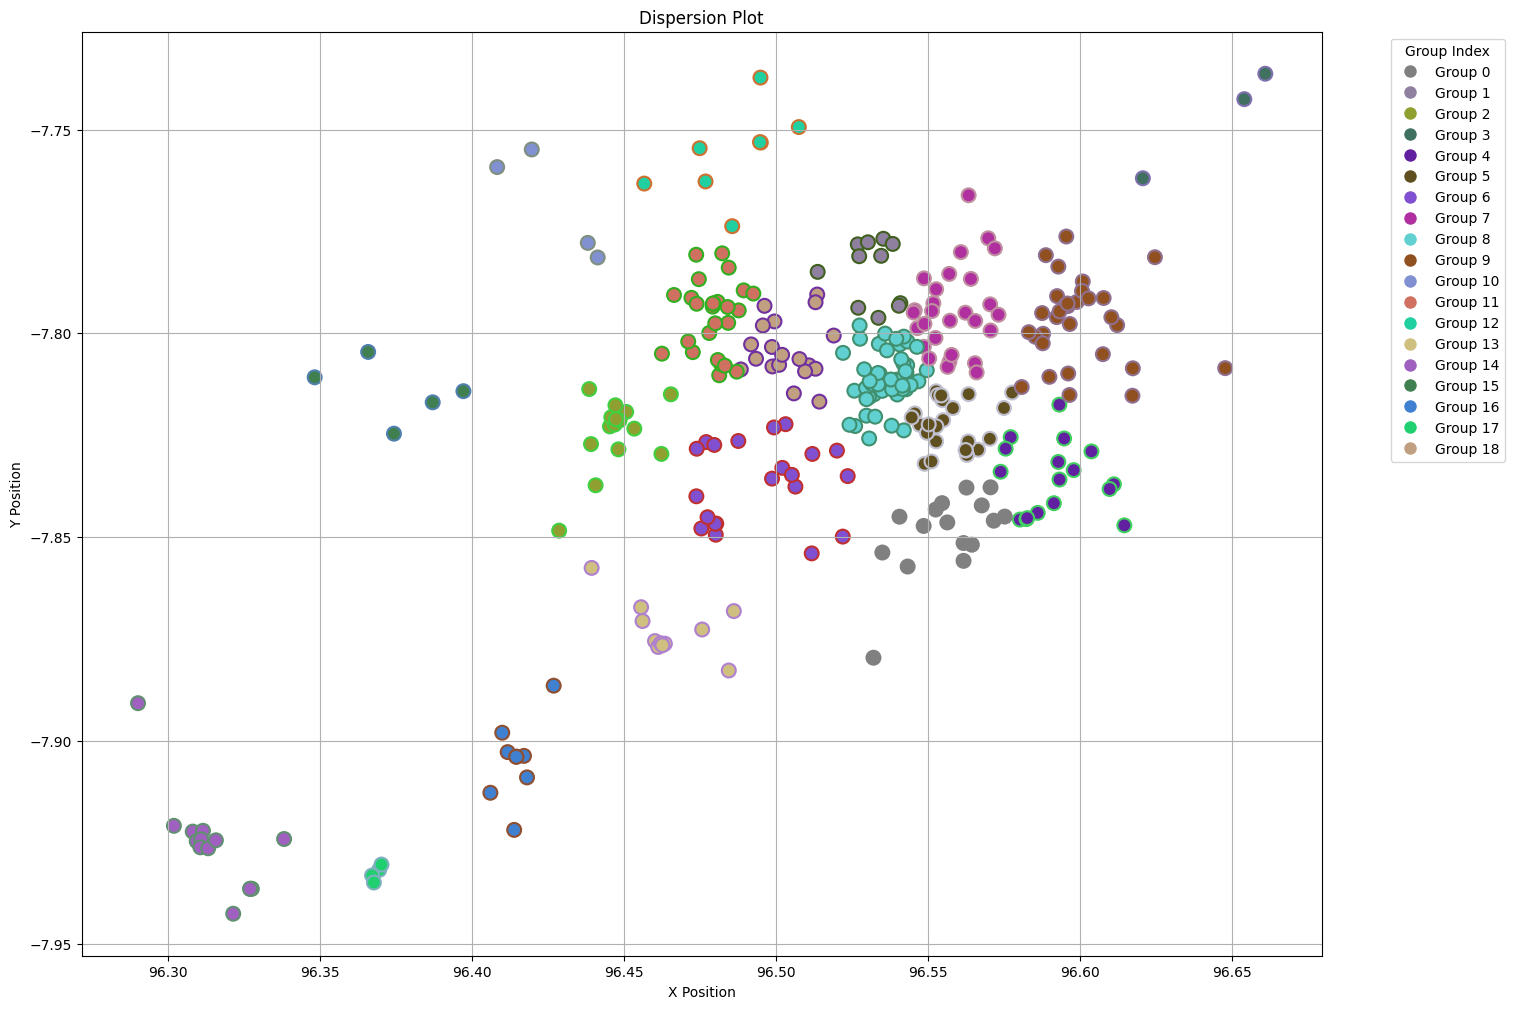

In [59]:
labels, prob, clusterer = clustering.run_Affinity_Propagation(data, params)

cplt.plot_clusters(X_data, Y_data, labels)
plt.show()

distances, dit_comp, dist_pur, overlap, overlap_comp, overlap_pur, overlap_f1 = print_overlaps(data, group, labels)

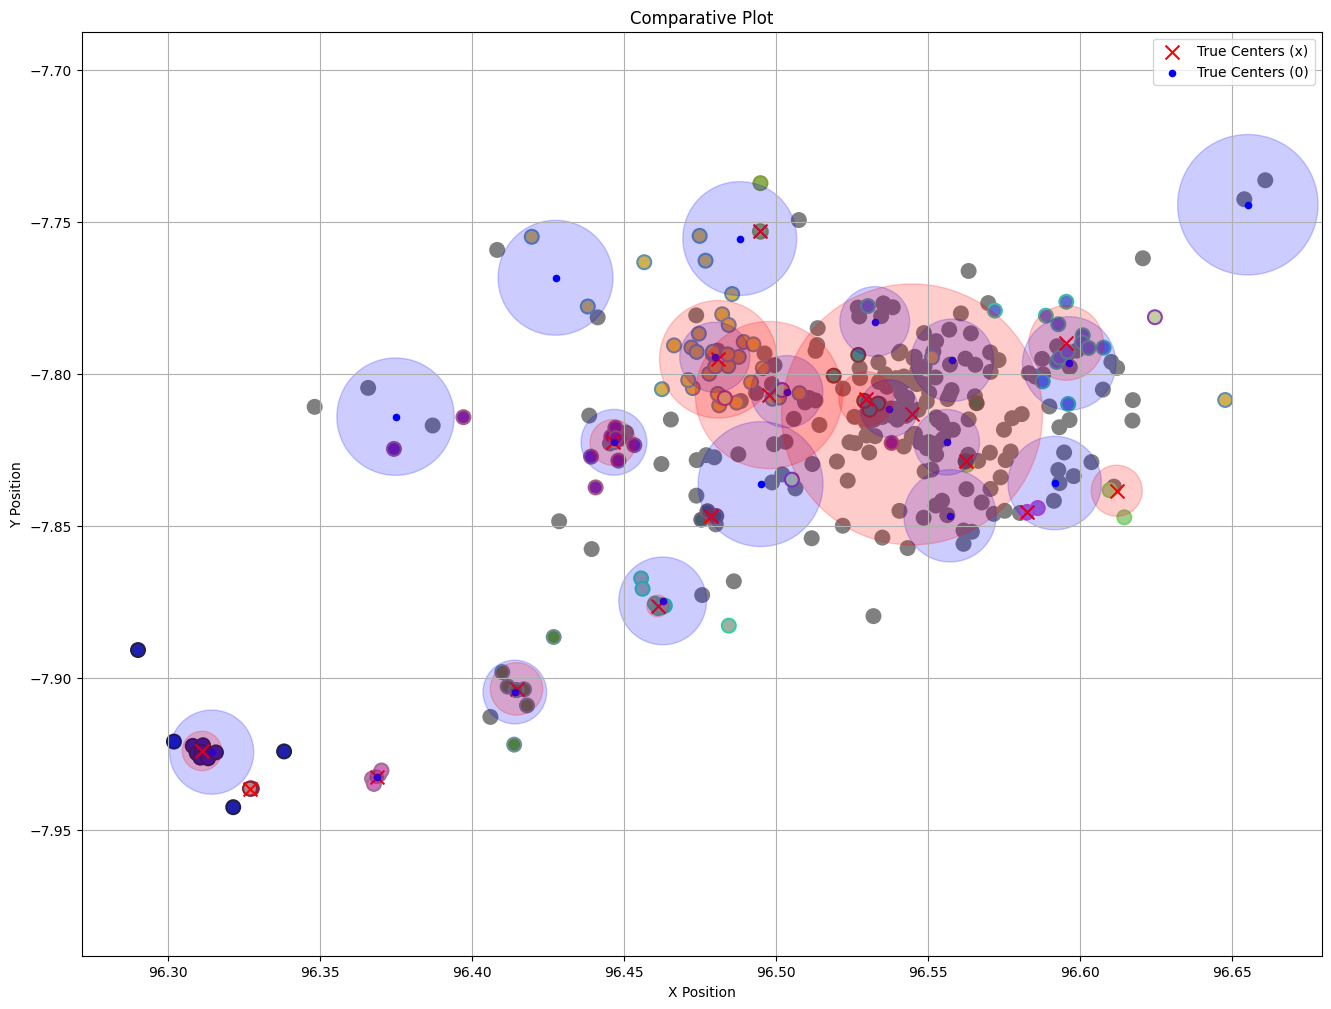

In [60]:
cplt.plot_comparative_clusters(X_data, Y_data, group, labels)
plt.show()

In [61]:
print("Completeness")
print(overlap_comp)

Completeness
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   0.0956  0.0694     0.0     0.0  0.0164  0.0632  0.0297  0.1001   
True 1   0.0000  0.0000     0.0     0.0  0.0000  0.0000  0.0000  0.0000   
True 2   0.0000  0.0000     0.0     0.0  0.0000  0.0000  0.0000  0.0000   
True 3   0.0000  0.0000     0.0     0.0  0.0000  0.0000  0.0000  0.0000   
True 4   0.0000  0.0000     0.0     0.0  0.0000  0.0000  0.0000  0.0000   
True 5   0.0000  0.0000     1.0     0.0  0.0000  0.0000  0.0000  0.0000   
True 6   0.0000  0.0000     0.0     0.0  0.0000  0.0000  0.7581  0.0000   
True 7   0.0000  0.0000     0.0     0.0  0.0000  0.0000  0.0000  0.0000   
True 8   0.0000  0.0000     0.0     0.0  0.0000  0.0000  0.0000  0.0000   
True 9   0.0000  0.0000     0.0     0.0  0.0000  0.0000  0.0000  0.0000   
True 10  0.0000  0.0000     0.0     0.0  0.0000  0.0000  0.1937  0.0000   
True 11  0.0000  0.0000     0.0     0.0  0.0000  0.0000  0.0000  0.0000   
True 12  0.0

In [62]:
print("Purity")
print(overlap_pur)

Purity
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0   0.7646  0.9682  0.0000     0.0  0.1280  1.0000  0.1297     1.0   
True 1   0.0000  0.0000  0.0000     0.0  0.0000  0.0000  0.0000     0.0   
True 2   0.0000  0.0000  0.0000     0.0  0.0000  0.0000  0.0000     0.0   
True 3   0.0000  0.0000  0.0000     0.0  0.0000  0.0000  0.0000     0.0   
True 4   0.0000  0.0000  0.0000     0.0  0.0000  0.0000  0.0000     0.0   
True 5   0.0000  0.0000  0.4843     0.0  0.0000  0.0000  0.0000     0.0   
True 6   0.0000  0.0000  0.0000     0.0  0.0000  0.0000  0.0105     0.0   
True 7   0.0000  0.0000  0.0000     0.0  0.0000  0.0000  0.0000     0.0   
True 8   0.0000  0.0000  0.0000     0.0  0.0000  0.0000  0.0000     0.0   
True 9   0.0000  0.0000  0.0000     0.0  0.0000  0.0000  0.0000     0.0   
True 10  0.0000  0.0000  0.0000     0.0  0.0000  0.0000  0.2689     0.0   
True 11  0.0000  0.0000  0.0000     0.0  0.0000  0.0000  0.0000     0.0   
True 12  0.0000  0

In [63]:
print("F1 Score")
print(overlap_f1)

F1 Score
         Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0     0.17  0.1294     NaN     NaN  0.0291  0.1190  0.0484   0.182   
True 1      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 2      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 3      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 4      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 5      NaN     NaN  0.6526     NaN     NaN     NaN     NaN     NaN   
True 6      NaN     NaN     NaN     NaN     NaN     NaN  0.0207     NaN   
True 7      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 8      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 9      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 10     NaN     NaN     NaN     NaN     NaN     NaN  0.2252     NaN   
True 11     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
True 12     NaN 

Metodos

K-means
Aglomerative clustering
Affinity propagation
BIRCH

GMM

DBSCAN
HDBSCAN
OPTICS


Tests

Comparar Prbabilidad 2D vs 3D
Cambiar parametros y metricas 
Agregar perturbaciones a los datos (MTC simulación)
Manejar ruido -> galaxias del halo principal, galaxias de fondo


Metodos Adicionales

Self organizing maps

Test adicionales

Combinar tecnicas

Kernel Density Estimation

Por membresía

1.- Asigno bien galaxias como si fueran subestructuras independiente de si la subestructura es la correcta.
2.- Las subestructuras encontradas correpsonden a subestructuras reales (No necesariamente la misma suestructuras, las encontradas pueden ser particiones, mezclas o combinaciones de reales). Se puede determinar por distancia centro-centro o por membresía.
3.- Post procesamiento de subestructuras encontradas, unir o separar subestructuras para replicar mejor subestructuras reales
4.- Determinar que tan correctas son las nuevas subestructuras encontradas

(Multinomial con mu -> varía con distancia a baricentros de las subestructuras) Probabilidad a cluster 1 dado que probabilidad a cluster2...
Cuanto más lejos de otros clusteres mu aumenta

machine learning kevin murphey, proceso de dirichleit

Testeo por areas de vecindario para algoritmos de clsutering:

Descartar todos los miembros del grupo que queden fuera del area.
Si el cluster queda con 3 miembros o menos es descartado.
Dejar el centro como centro